# PA1 Tasks 2 + 3 - full re-run on Kaggle (nothing restored)

**Why.** Every Task 2 and Task 3 run is trained again from scratch under the handout protocol (seed 6304,
no gradient clipping, frozen BatchNorm statistics, AdamW 1e-4, at most 30 epochs, patience 5). Nothing from
an earlier session is loaded, so the results can be set against the originals to see whether anything
changes from run to run.

**What a re-run can and cannot tell you.** The seed is fixed, so this run differs from the original only
through numerical noise: different GPU (Colab vs Kaggle) and a few GPU kernels that are not bit-exact.
- A healthy run should land within about a point of the original.
- A collapse that happens again is systematic, not a fluke of one session.
- A result that **flips** (collapses once, trains the other time) sits on a knife-edge. That is "something
  else at play", and it belongs in the report.

A fixed-seed re-run cannot say whether seed 6304 itself was unlucky. **Part H1** checks that by repeating the
two MMD collapse runs with seed 6305. That is a labelled robustness check, never a comparison.

| Part | What happens | Runs trained |
|---|---|---|
| A | GPU check, fresh working copy, protocol, data, helpers | - |
| B | Task 2 training | source_only, dan, dann, cdan, dan λ 0.1 / 10, dann α_max 0.25 / 0.5 |
| C | Task 2 evaluation (the only use of Sketch labels in Task 2) | - |
| D | Task 3 training. **ERM = the source_only trained in Part B** | dan_dg, sam, dan_dg λ 0.1 / 10 |
| E | Task 3 source-side evaluation + collapse diagnosis (no Sketch) | - |
| F | Task 3 Sketch evaluation (the only Sketch access in Task 3) | - |
| G | Original vs re-run for every run, then save everything | - |
| H1 | Seed check with seed 6305 | dan λ 10 (Task 2), dan_dg λ 1 (Task 3) |
| H2 | Estimator switch: unbiased MMD, diagnostic. **Last cell** | diag_dan_dg_unbiased |

**Datasets to attach:** `pa1-repo`, `pa1-task2-b`, `pa1-task3` (**upload the v3 zip as a new version**),
`pacs-dataset`. You do **not** need `erm-checkpoint` or `task3-runs`: the Task 3 ERM is the Source-only model
re-trained in Part B, which is how the handout defines it.

**Timing.** Probably 3-5 hours on one GPU; every run prints its own training time. Kaggle allows 12 hours
per commit. Use **Save Version -> Save & Run All (Commit)**. Results are copied to `/kaggle/working/outputs/`
after every Part, so a failure late in the notebook does not lose the earlier Parts.

**Expected verdicts** (from the original runs): STABLE for source_only, dan, dan λ 0.1, sam, dan_dg λ 0.1;
COLLAPSED for dan λ 10, dann, dann α_max 0.5, dan_dg (λ 1), dan_dg λ 10; DEGRADED for cdan and dann α_max 0.25.
Part G flags every run whose verdict differs from the original.

## Part A - setup

In [3]:
# A0. Hard GPU check -- before anything else. (An earlier session trained on the CPU without noticing.)
# Kaggle: Settings (right panel) -> Accelerator -> GPU P100 or GPU T4 x2, then Run All again.
import torch
if not torch.cuda.is_available():
    raise RuntimeError('NO GPU -- Settings -> Accelerator -> GPU, then Run All again.')
print('GPU:', torch.cuda.get_device_name(0), '| torch', torch.__version__)

GPU: Tesla T4 | torch 2.10.0+cu128


In [4]:
# A1. Assemble a FRESH working copy of the repo from the attached code datasets, then delete any results
# folders that came bundled with them. Nothing trained in an earlier session can be used below.
# (/kaggle/input is read-only; everything happens in /kaggle/working.)
import os, glob, shutil, json, math, subprocess, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = '/kaggle/working/PA1'
OUT  = '/kaggle/working/outputs'

# Find the attached datasets by what is INSIDE them, so the account name, the dataset names and how Kaggle
# nested the unzipped folders do not matter.
def roots_with(marker):
    hits = glob.glob(f'/kaggle/input/**/{marker}', recursive=True)
    return sorted({h[: -len(marker) - 1] for h in hits})

repo_roots = roots_with('shared/splits/pacs_sources_seed6304.json')        # your GitHub repo zip
t2_roots = roots_with('task2/train.py')                                      # Task 2 code (usually the same zip)
t3_roots = [r for r in roots_with('task3/train.py')
            if 'seed_check' in open(f'{r}/task3/train.py').read()]           # the v3 zip
assert repo_roots, ('No attached dataset contains shared/splits/pacs_sources_seed6304.json. '
                    'Upload your GitHub repo (Code -> Download ZIP) as a dataset and attach it.')
assert t2_roots, 'No attached dataset contains task2/train.py -- the GitHub repo zip should include it.'
assert t3_roots, 'No attached dataset contains the v3 Task 3 code. Upload pa1-task3-v3.zip as a dataset and attach it.'
if len(t2_roots) > 1:
    print(f'  WARNING: Task 2 code found in {len(t2_roots)} datasets; the last one wins: {t2_roots}')
# later layers overwrite earlier ones: repo first, then Task 2 code, then the v3 zip LAST
LAYERS = [r for r in dict.fromkeys(repo_roots[:1] + t2_roots) if r != t3_roots[0]] + [t3_roots[0]]

os.makedirs(REPO, exist_ok=True); os.makedirs(OUT, exist_ok=True)
for layer in LAYERS:
    shutil.copytree(layer, REPO, dirs_exist_ok=True, ignore=shutil.ignore_patterns('results', '.git'))
    print(f'  layered in: {layer}  (any results/ folder inside it was NOT copied)')
os.chdir(REPO)

# First time A1 runs in this session: make sure no results exist. If you re-run A1 later in the SAME
# session, the marker keeps the runs you have trained since then.
MARKER = f'{REPO}/.fresh_rerun_session'
if not os.path.exists(MARKER):
    for d in ['task2/results', 'task3/results']:
        if os.path.isdir(d):
            shutil.rmtree(d); print(f'  deleted old {d}/')
    open(MARKER, 'w').write(time.ctime())
    print('  fresh session: no earlier results exist in the working copy')
else:
    print('  A1 re-run inside the same session: keeping the runs trained since the session started')

# PACS: the folder that holds photo/, art_painting/, cartoon/ and sketch/ side by side
pacs_hits = [os.path.dirname(p) for p in glob.glob('/kaggle/input/**/sketch', recursive=True)
             if all(os.path.isdir(f'{os.path.dirname(p)}/{d}') for d in ['photo', 'art_painting', 'cartoon'])]
assert pacs_hits, 'PACS not found: attach a dataset with photo/, art_painting/, cartoon/, sketch/ folders.'
PACS = pacs_hits[0]
T2_RUNS, T2_FINAL = 'task2/results/runs', 'task2/results/final'
T3_RUNS, T3_FINAL = 'task3/results/runs', 'task3/results/final'
T3_EVAL = f'--set data_root={PACS} erm_checkpoint={T2_RUNS}/source_only/best.pt'   # for Task 3's evaluation scripts

NEEDED = ['common/io.py', 'common/seed.py', 'task2/train.py', 'task2/evaluate_final.py', 'task3/train.py', 'task3/evaluate_sources.py',
          'task3/evaluate_sketch.py', 'task3/diagnose_collapse.py', 'task3/configs/diag_dan_dg_unbiased.yaml',
          'shared/engine.py', 'shared/mmd.py', 'shared/splits/pacs_sources_seed6304.json',
          'shared/splits/pacs_sketch_target.json'] + \
         [f'task2/configs/{c}.yaml' for c in ['source_only', 'dan', 'dann', 'cdan', 'study_dan_lambda0.1',
          'study_dan_lambda10', 'study_dann_alpha0.25', 'study_dann_alpha0.5']] + \
         [f'task3/configs/{c}.yaml' for c in ['dan_dg', 'sam', 'study_dan_dg_lambda0.1', 'study_dan_dg_lambda10']]
missing = [f for f in NEEDED if not os.path.exists(f)]
new_code = 'unbiased' in open('shared/mmd.py').read() and 'seed_check' in open('task3/train.py').read()
print(f'\n  repo    : {sorted(os.listdir(REPO))}')
print(f'  PACS    : {PACS}')
print(f'  v3 code : {"yes" if new_code else "NO -- upload the v3 zip as a new version of pa1-task3"}')
print(f'  MISSING : {missing if missing else "nothing -- ready"}')
assert not missing and new_code

  layered in: /kaggle/input/datasets/talhaimran27/pa1-repo/CS6304_ATML_PA1-main  (any results/ folder inside it was NOT copied)
  layered in: /kaggle/input/datasets/talhaimran27/pa1-task3  (any results/ folder inside it was NOT copied)
  A1 re-run inside the same session: keeping the runs trained since the session started

  repo    : ['.fresh_rerun_session', '.gitignore', 'README.md', 'common', 'notebooks', 'report', 'requirements.txt', 'shared', 'task1', 'task2', 'task3']
  PACS    : /kaggle/input/datasets/talhaimran27/pacs-dataset/PACS
  v3 code : yes
  MISSING : nothing -- ready


In [5]:
# A2. The protocol. Task 2 and Task 3 share task2/configs/base.yaml. Gradient clipping is set to 0.0: the
# handout specifies none, and the original main results (runs_clip0.0) used none.
os.system("sed -i 's/^grad_clip: .*/grad_clip: 0.0          # handout protocol: no gradient clipping/' task2/configs/base.yaml")
from common.io import load_config
t2, t3 = load_config('task2/configs/base.yaml'), load_config('task3/configs/base.yaml')
KEYS = ['seed', 'num_workers', 'per_domain_batch', 'target_batch', 'lr', 'weight_decay', 'grad_clip',
        'max_epochs', 'patience']
display(pd.DataFrame([{'setting': k, 'Task 2': t2.get(k), 'Task 3': t3.get(k)} for k in KEYS]))
print(f"Task 2 results -> {t2['results_dir']}")
print(f"Task 3 results -> {t3['results_dir']}")
print(f"Task 3 ERM     -> {t3['erm_checkpoint']}   (the Source-only model Part B is about to train)")
assert t2['grad_clip'] == 0.0 and t2['seed'] == 6304 and t3['erm_checkpoint'].startswith(T2_RUNS)

,setting,Task 2,Task 3
0,seed,6304.0000,6304.0000
1,num_workers,2.0000,2.0000
2,per_domain_batch,8.0000,8.0000
3,target_batch,24.0000,24.0000
4,lr,0.0001,0.0001
5,weight_decay,0.0001,0.0001
6,grad_clip,0.0000,0.0000
7,max_epochs,30.0000,30.0000
8,patience,5.0000,5.0000


Task 2 results -> task2/results/runs
Task 3 results -> task3/results/runs
Task 3 ERM     -> task2/results/runs/source_only/best.pt   (the Source-only model Part B is about to train)


In [6]:
# A3. Data check. The splits ship with the repo and must match this PACS copy image for image.
EXPECTED = {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}
for d, n in EXPECTED.items():
    got = len([p for p in glob.glob(f'{PACS}/{d}/*/*') if p.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'  {d:13s} {got:5d}  (expected {n})' + ('' if got == n else '   <-- MISMATCH, stop here'))
    assert got == n
src = json.load(open('shared/splits/pacs_sources_seed6304.json'))['domains']
tr = sum(len(s['train']) for s in src.values())
for d, s in src.items():
    print(f'  {d:13s} train={len(s["train"]):5d}  val={len(s["val"]):4d}')
print(f'\n  one epoch = {tr} // 24 = {tr // 24} updates; 30-epoch budget = {30 * (tr // 24)} updates')

  photo          1670  (expected 1670)
  art_painting   2048  (expected 2048)
  cartoon        2344  (expected 2344)
  sketch         3929  (expected 3929)
  photo         train= 1336  val= 334
  art_painting  train= 1638  val= 410
  cartoon       train= 1875  val= 469

  one epoch = 4849 // 24 = 202 updates; 30-epoch budget = 6060 updates


In [7]:
# A4. Helpers.
#   run(cmd)      runs a script and streams its output
#   train(...)    trains one run (skips it only if it was already trained IN THIS SESSION), then report()
#   report(...)   health summary + curves; returns a summary row
#   ORIGINAL      the numbers from the original sessions, for the run-to-run comparison in Part G
CHANCE_LOSS = math.log(7)   # 1.946: uniform guessing over 7 classes (a fresh head starts here)
PRIOR_LOSS = 1.913          # always predicting the source class frequencies: features carry no class info

def run(cmd):
    print('$', cmd, flush=True)
    t0 = time.time()
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
    if p.wait() != 0:
        raise RuntimeError(f'Command failed (exit code {p.returncode}): {cmd}')
    print(f'  [{(time.time() - t0) / 60:.1f} min]')

def verdict(s, hist):
    cls = [h['loss_cls'] for h in hist]; f1 = [h['val_mean_macro_f1'] for h in hist]
    gn = [h.get('grad_norm', float('nan')) for h in hist]
    if min(cls) > 1.6 or s['best_mean_macro_f1'] < 50:
        return 'COLLAPSED'
    if f1[-1] < s['best_mean_macro_f1'] - 10 or cls[-1] > max(0.5, 3 * min(cls)) or max(gn) > 1e3:
        return 'DEGRADED'
    return 'STABLE' if s['best_mean_macro_f1'] >= 90 else 'WEAK'

def report(runs_dir, run_name):
    '''What to look for:
       loss_cls   must end far below 1.95. Stuck at 1.91-1.95 = the head only learned class frequencies.
       loss_mmd   MMD penalty. The biased estimator cannot go below ~0.15 (24 vs 24, Task 2) or ~0.47
                  (8 vs 8, Task 3) even for identical domains, and its offset pulls features smaller.
       loss_dom   DANN/CDAN domain loss; 0.69 = discriminator guessing. Huge values = the runaway.
       loss_sam   SAM's loss at theta+eps; the gap above loss_cls should shrink.
       feat_norm  DAN-DG only: mean feature norm. Falling + loss_cls stuck = the collapse signature.'''
    d = f'{runs_dir}/{run_name}'
    s, hist = json.load(open(f'{d}/summary.json')), json.load(open(f'{d}/history.json'))
    ep = [h['epoch'] for h in hist]; f1 = [h['val_mean_macro_f1'] for h in hist]
    cls = [h['loss_cls'] for h in hist]; gn = [h.get('grad_norm', float('nan')) for h in hist]
    best_ep = ep[int(pd.Series(f1).idxmax())]
    minutes = sum(h.get('time_s', 0) for h in hist) / 60
    v = verdict(s, hist)
    print(f'\n=== {run_name} ===   ({minutes:.1f} min of training, seed {s["config"]["seed"]})')
    print(f'  epochs run              : {s["epochs_run"]} of {s["config"]["max_epochs"]}'
          f' ({"early stop" if s["epochs_run"] < s["config"]["max_epochs"] else "full budget"})')
    print(f'  best source-val macro-F1: {s["best_mean_macro_f1"]:.2f} (epoch {best_ep}), last epoch {f1[-1]:.2f}')
    print(f'  classification loss     : {cls[0]:.3f} -> {cls[-1]:.3f}  (min {min(cls):.3f}; 1.95 chance, 1.91 = class frequencies only)')
    for k, lab in [('loss_mmd', 'MMD penalty'), ('loss_dom', 'domain loss'), ('loss_sam', 'loss at theta+eps'),
                   ('feat_norm', 'feature norm |F(x)|')]:
        if k in hist[0]:
            print(f'  {lab:24s}: {hist[0][k]:.3f} -> {hist[-1][k]:.3f}')
    if 'disc_acc' in hist[0]:
        print(f'  discriminator accuracy  : {100*hist[0]["disc_acc"]:.1f}% -> {100*hist[-1]["disc_acc"]:.1f}%  (50% = confused)')
    print(f'  max gradient norm       : {max(gn):.3g}')
    orig = ORIGINAL.get(run_name)
    if orig and orig['f1'] is not None:
        flag = '' if orig['verdict'] == v else '   <-- VERDICT CHANGED'
        print(f'  ORIGINAL run            : F1 {orig["f1"]:.2f}, {orig["epochs"]} epochs, {orig["verdict"]}{flag}')
    print(f'  VERDICT: {v}')

    panels = [('loss_cls', 'classification loss', CHANCE_LOSS)]
    for k, t in [('loss_mmd', 'MMD penalty'), ('loss_dom', 'domain loss'), ('disc_acc', 'discriminator acc'),
                 ('loss_sam', 'loss at theta+eps'), ('feat_norm', 'feature norm')]:
        if k in hist[0]: panels.append((k, t, None))
    panels += [('val_mean_macro_f1', 'mean source-val macro-F1', None), ('grad_norm', 'gradient norm', None)]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 2.6))
    for ax, (k, title, line) in zip(axes, panels):
        y = [h.get(k, float('nan')) for h in hist]
        ax.plot(ep, y, marker='.')
        if k in ('grad_norm', 'loss_dom') and np.nanmax(y) > 100: ax.set_yscale('log')
        if line: ax.axhline(line, color='r', ls=':', lw=1)
        ax.set_title(f'{run_name}: {title}', fontsize=8); ax.set_xlabel('epoch'); ax.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(f'{OUT}/curves_{run_name}.png', dpi=130); plt.show(); plt.close(fig)
    return {'run': run_name, 'epochs': s['epochs_run'], 'best_epoch': best_ep,
            'best_src_val_f1': round(s['best_mean_macro_f1'], 2), 'last_src_val_f1': round(f1[-1], 2),
            'min_loss_cls': round(min(cls), 3), 'max_grad_norm': float(f'{max(gn):.3g}'),
            'train_minutes': round(minutes, 1), 'verdict': v}

summary_rows = {}
def train(task, config, run_name, extra=''):
    runs_dir = T2_RUNS if task == 2 else T3_RUNS
    if os.path.exists(f'{runs_dir}/{run_name}/summary.json'):
        print(f'{run_name}: already trained in THIS session -- skipping (nothing from earlier sessions exists here)')
    else:
        common = f'--set data_root={PACS}' + (f' erm_checkpoint={T2_RUNS}/source_only/best.pt' if task == 3 else '')
        run(f'python -m task{task}.train --config task{task}/configs/{config}.yaml {common} {extra}')
    summary_rows[run_name] = {'task': task, **report(runs_dir, run_name)}
    pd.DataFrame(summary_rows.values()).to_csv(f'{OUT}/training_summary.csv', index=False)

# Originals: Task 2 from the Colab runs_clip0.0 folder, Task 3 from the Kaggle CPU session.
ORIGINAL = {
    'source_only':      dict(task=2, epochs=20, f1=94.14, sketch=69.59, sep=99.86, verdict='STABLE'),
    'dan':              dict(task=2, epochs=15, f1=95.02, sketch=58.59, sep=82.28, verdict='STABLE'),
    'dann':             dict(task=2, epochs=23, f1=35.04, sketch=26.44, sep=98.08, verdict='COLLAPSED'),
    'cdan':             dict(task=2, epochs=6,  f1=88.75, sketch=58.49, sep=99.45, verdict='DEGRADED'),
    'dan_lambda0.1':    dict(task=2, epochs=13, f1=93.90, sketch=67.01, sep=97.25, verdict='STABLE'),
    'dan_lambda10':     dict(task=2, epochs=6,  f1=5.07,  sketch=4.07,  sep=68.27, verdict='COLLAPSED'),
    'dann_alpha0.25':   dict(task=2, epochs=6,  f1=88.75, sketch=52.30, sep=99.73, verdict='DEGRADED'),
    'dann_alpha0.5':    dict(task=2, epochs=6,  f1=44.74, sketch=15.47, sep=100.0, verdict='COLLAPSED'),
    'dan_dg':           dict(task=3, epochs=6,  f1=5.07,  sketch=None,  sep=None,  verdict='COLLAPSED'),
    'sam':              dict(task=3, epochs=13, f1=95.60, sketch=None,  sep=None,  verdict='STABLE'),
    'dan_dg_lambda0.1': dict(task=3, epochs=None, f1=None, sketch=None, sep=None, verdict='not finished'),
    'dan_dg_lambda10':  dict(task=3, epochs=None, f1=None, sketch=None, sep=None, verdict='never run'),
}
print('Helpers ready.')

Helpers ready.


## Part B - Task 2 training

Batches: 8 photo + 8 art + 8 cartoon (labelled) + 24 Sketch images **without labels** (the transductive UDA
protocol). Sketch labels are used only in Part C, after all eight runs are fixed.

$ python -m task2.train --config task2/configs/source_only.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth

  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 23%|██▎       | 10.4M/44.7M [00:00<00:00, 109MB/s]
 75%|███████▍  | 33.4M/44.7M [00:00<00:00, 186MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]
[source_only] ep01 loss_cls=0.5543 loss_total=0.5543 | val mean F1=90.03
[source_only] ep02 loss_cls=0.2393 loss_total=0.2393 | val mean F1=92.14
[source_only] ep03 loss_cls=0.1479 loss_total=0.1479 | val mean F1=92.95
[source_only] ep04 loss_cls=0.1342 loss_total=0.1342 | val mean F1=92.02
[source_only] ep05 loss_cls=0.1146 loss_total=0.1146 | val mean F1=91.18
[source_only] ep06 loss_cls=0.0960 loss_total=0.0960 | val mean F1=92.63
[source_only] ep07 loss_cls=0.0799 loss_total=0.0799 | val mean F1=93.22
[source_only] ep08 l

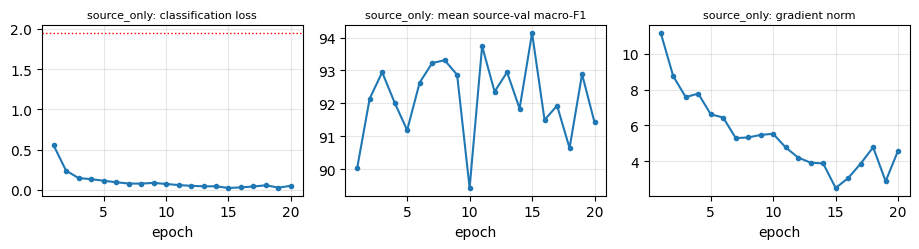

In [8]:
# B1. Source-only ERM. This model is ALSO the Task 3 ERM baseline (Part D compares against it).
# Expect STABLE, source-val F1 around 94.
train(2, 'source_only', 'source_only')

$ python -m task2.train --config task2/configs/dan.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dan] ep01 loss_cls=0.5670 loss_mmd=0.2291 loss_total=0.7961 | val mean F1=87.75
[dan] ep02 loss_cls=0.2412 loss_mmd=0.1980 loss_total=0.4391 | val mean F1=92.21
[dan] ep03 loss_cls=0.1697 loss_mmd=0.1845 loss_total=0.3542 | val mean F1=91.63
[dan] ep04 loss_cls=0.1173 loss_mmd=0.1771 loss_total=0.2944 | val mean F1=93.32
[dan] ep05 loss_cls=0.0889 loss_mmd=0.1712 loss_total=0.2601 | val mean F1=94.03
[dan] ep06 loss_cls=0.0777 loss_mmd=0.1703 loss_total=0.2480 | val mean F1=92.46
[dan] ep07 loss_cls=0.0755 loss_mmd=0.1662 loss_total=0.2417 | val mean F1=93.39
[dan] ep08 loss_cls=0.0746 loss_mmd=0.1636 loss_total=0.2382 | val mean F1=93.59
[dan] ep09 loss_cls=0.0708 loss_mmd=0.1629 loss_total=0.2338 | val mean F1=93.09
[dan] ep10 loss_cls=0.0631 loss_mmd=0.1696 loss_total=0.2327 | val mean F1=95.02
[dan] ep11 loss_cls=0.0528 loss_mmd=0.1692 loss_total=0.2220 | 

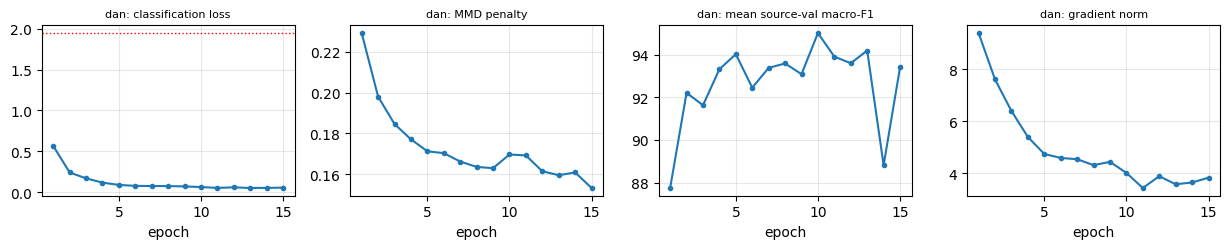

$ python -m task2.train --config task2/configs/dann.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dann] ep01 loss_cls=50.3247 loss_dom=514.2894 disc_acc=0.5357 alpha=0.0825 loss_total=564.6142 | val mean F1=4.55
[dann] ep02 loss_cls=9.1166 loss_dom=36.6559 disc_acc=0.4970 alpha=0.2440 loss_total=45.7725 | val mean F1=4.99
[dann] ep03 loss_cls=13.9007 loss_dom=36.4407 disc_acc=0.5000 alpha=0.3930 loss_total=50.3414 | val mean F1=5.59
[dann] ep04 loss_cls=3.6972 loss_dom=3.3426 disc_acc=0.5339 alpha=0.5239 loss_total=7.0398 | val mean F1=6.47
[dann] ep05 loss_cls=2.1820 loss_dom=0.6421 disc_acc=0.6251 alpha=0.6340 loss_total=2.8241 | val mean F1=8.19
[dann] ep06 loss_cls=2.0142 loss_dom=0.6241 disc_acc=0.6309 alpha=0.7233 loss_total=2.6383 | val mean F1=6.37
[dann] ep07 loss_cls=1.9430 loss_dom=0.6509 disc_acc=0.5891 alpha=0.7936 loss_total=2.5939 | val mean F1=8.97
[dann] ep08 loss_cls=1.9151 loss_dom=0.6713 disc_acc=0.5784 alpha=0.8476 loss_total=2.5864 |

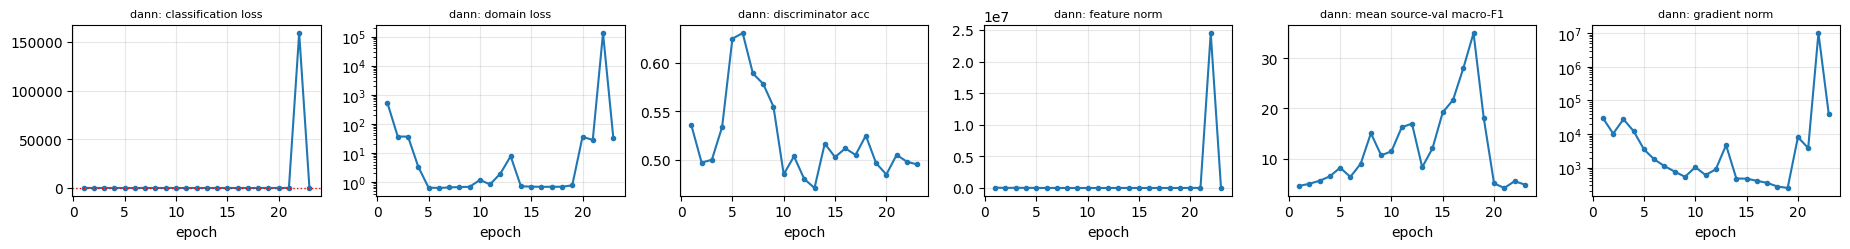

$ python -m task2.train --config task2/configs/cdan.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[cdan] ep01 loss_cls=0.5685 loss_dom=0.5062 disc_acc=0.7770 alpha=0.0825 loss_total=1.0746 | val mean F1=88.75
[cdan] ep02 loss_cls=0.7411 loss_dom=1.6176 disc_acc=0.5888 alpha=0.2440 loss_total=2.3587 | val mean F1=59.14
[cdan] ep03 loss_cls=3.6994 loss_dom=5.7035 disc_acc=0.4953 alpha=0.3930 loss_total=9.4028 | val mean F1=10.28
[cdan] ep04 loss_cls=1.8486 loss_dom=0.6776 disc_acc=0.5661 alpha=0.5239 loss_total=2.5263 | val mean F1=12.40
[cdan] ep05 loss_cls=1.7190 loss_dom=0.6755 disc_acc=0.5778 alpha=0.6340 loss_total=2.3945 | val mean F1=15.56
[cdan] ep06 loss_cls=1.7451 loss_dom=0.7947 disc_acc=0.5452 alpha=0.7233 loss_total=2.5398 | val mean F1=27.36
early stop at epoch 6 (best mean macro-F1 88.75)
  [3.8 min]

=== cdan ===   (3.7 min of training, seed 6304)
  epochs run              : 6 of 30 (early stop)
  best source-val macro-F1: 88.75 (epoch 1), la

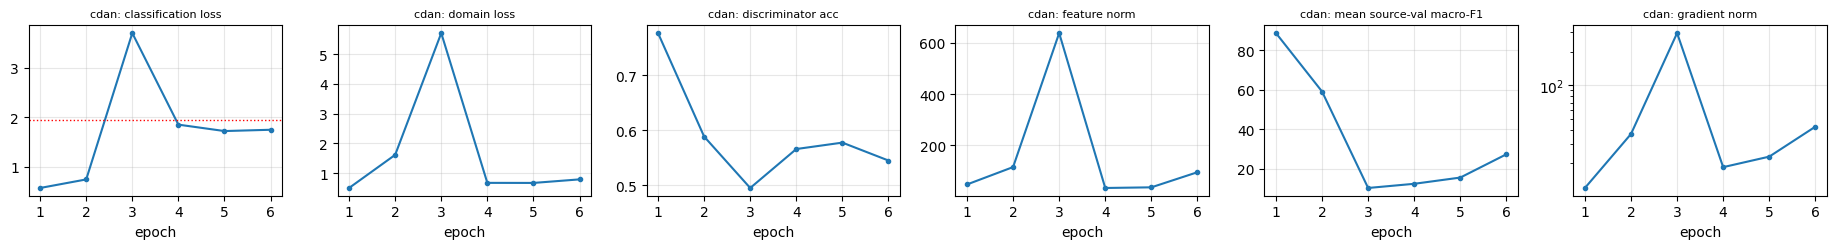

In [9]:
# B2. The three alignment methods at their main settings.
#   dan   lambda_MMD = 1                        expect STABLE (~95)
#   dann  gradient reversal, alpha_max = 1      expect COLLAPSED: the reversed domain loss is unbounded
#   cdan  discriminator sees f (x) p            expect DEGRADED: learns, then blows up
for config, name in [('dan', 'dan'), ('dann', 'dann'), ('cdan', 'cdan')]:
    train(2, config, name)

$ python -m task2.train --config task2/configs/study_dan_lambda0.1.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dan_lambda0.1] ep01 loss_cls=0.5238 loss_mmd=0.3635 loss_total=0.5601 | val mean F1=88.94
[dan_lambda0.1] ep02 loss_cls=0.2356 loss_mmd=0.2639 loss_total=0.2620 | val mean F1=89.79
[dan_lambda0.1] ep03 loss_cls=0.1380 loss_mmd=0.2383 loss_total=0.1618 | val mean F1=93.41
[dan_lambda0.1] ep04 loss_cls=0.1009 loss_mmd=0.2172 loss_total=0.1227 | val mean F1=91.03
[dan_lambda0.1] ep05 loss_cls=0.1030 loss_mmd=0.2191 loss_total=0.1249 | val mean F1=93.44
[dan_lambda0.1] ep06 loss_cls=0.0987 loss_mmd=0.2170 loss_total=0.1204 | val mean F1=93.04
[dan_lambda0.1] ep07 loss_cls=0.0655 loss_mmd=0.2047 loss_total=0.0860 | val mean F1=92.02
[dan_lambda0.1] ep08 loss_cls=0.0652 loss_mmd=0.2038 loss_total=0.0856 | val mean F1=93.90
[dan_lambda0.1] ep09 loss_cls=0.0266 loss_mmd=0.1972 loss_total=0.0463 | val mean F1=93.29
[dan_lambda0.1] ep10 loss_cls=0.0505 l

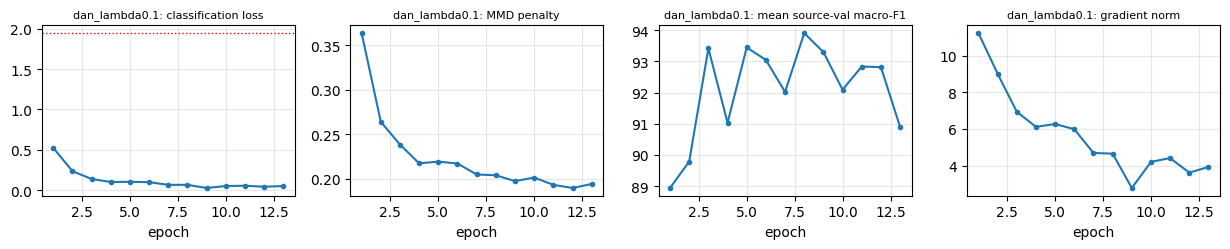

$ python -m task2.train --config task2/configs/study_dan_lambda10.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dan_lambda10] ep01 loss_cls=1.9432 loss_mmd=0.2469 loss_total=4.4127 | val mean F1=5.07
[dan_lambda10] ep02 loss_cls=1.9340 loss_mmd=0.2295 loss_total=4.2287 | val mean F1=5.07
[dan_lambda10] ep03 loss_cls=1.9295 loss_mmd=0.2183 loss_total=4.1121 | val mean F1=5.07
[dan_lambda10] ep04 loss_cls=1.9296 loss_mmd=0.2137 loss_total=4.0670 | val mean F1=5.07
[dan_lambda10] ep05 loss_cls=1.9316 loss_mmd=0.1992 loss_total=3.9236 | val mean F1=5.07
[dan_lambda10] ep06 loss_cls=1.9326 loss_mmd=0.2086 loss_total=4.0188 | val mean F1=5.07
early stop at epoch 6 (best mean macro-F1 5.07)
  [3.8 min]

=== dan_lambda10 ===   (3.7 min of training, seed 6304)
  epochs run              : 6 of 30 (early stop)
  best source-val macro-F1: 5.07 (epoch 1), last epoch 5.07
  classification loss     : 1.943 -> 1.933  (min 1.930; 1.95 chance, 1.91 = class frequencies only

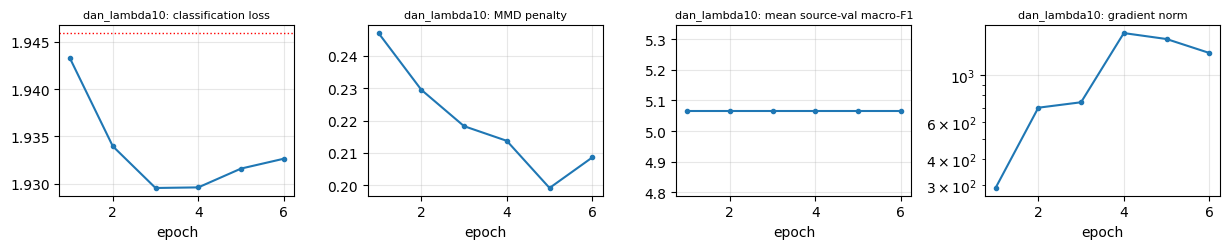

In [10]:
# B3. The declared controlled study: lambda_MMD in {0.1, 1, 10} (lambda = 1 is B2's dan).
# Expect lambda = 0.1 STABLE and lambda = 10 COLLAPSED (F1 5.07 = 'person' for every image).
for config, name in [('study_dan_lambda0.1', 'dan_lambda0.1'), ('study_dan_lambda10', 'dan_lambda10')]:
    train(2, config, name)

$ python -m task2.train --config task2/configs/study_dann_alpha0.25.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dann_alpha0.25] ep01 loss_cls=0.5590 loss_dom=0.2943 disc_acc=0.8855 alpha=0.0206 loss_total=0.8533 | val mean F1=88.75
[dann_alpha0.25] ep02 loss_cls=2699.1046 loss_dom=33645.1702 disc_acc=0.4216 alpha=0.0610 loss_total=36344.2752 | val mean F1=2.26
[dann_alpha0.25] ep03 loss_cls=5.2244 loss_dom=38.4301 disc_acc=0.4971 alpha=0.0983 loss_total=43.6545 | val mean F1=12.61
[dann_alpha0.25] ep04 loss_cls=6.7086 loss_dom=63.4202 disc_acc=0.5035 alpha=0.1310 loss_total=70.1289 | val mean F1=7.83
[dann_alpha0.25] ep05 loss_cls=13.3271 loss_dom=74.6105 disc_acc=0.4981 alpha=0.1585 loss_total=87.9375 | val mean F1=6.65
[dann_alpha0.25] ep06 loss_cls=9.4839 loss_dom=39.6769 disc_acc=0.5011 alpha=0.1808 loss_total=49.1607 | val mean F1=8.60
early stop at epoch 6 (best mean macro-F1 88.75)
  [3.8 min]

=== dann_alpha0.25 ===   (3.7 min of training, seed 

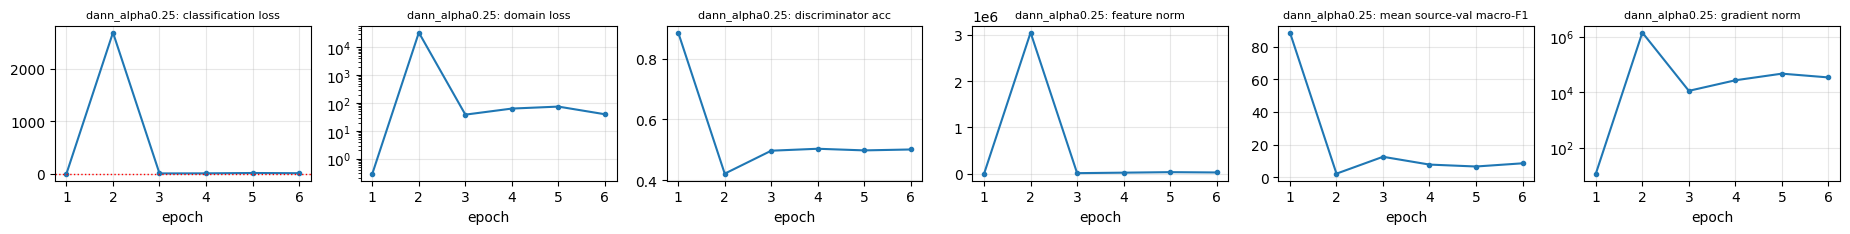

$ python -m task2.train --config task2/configs/study_dann_alpha0.5.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS 
[dann_alpha0.5] ep01 loss_cls=0.7395 loss_dom=5.9312 disc_acc=0.6768 alpha=0.0413 loss_total=6.6707 | val mean F1=44.74
[dann_alpha0.5] ep02 loss_cls=2.1438 loss_dom=14.8473 disc_acc=0.4789 alpha=0.1220 loss_total=16.9911 | val mean F1=5.96
[dann_alpha0.5] ep03 loss_cls=1.8872 loss_dom=0.7884 disc_acc=0.4886 alpha=0.1965 loss_total=2.6756 | val mean F1=28.01
[dann_alpha0.5] ep04 loss_cls=2.9672 loss_dom=5.7924 disc_acc=0.4508 alpha=0.2620 loss_total=8.7596 | val mean F1=5.99
[dann_alpha0.5] ep05 loss_cls=200.8512 loss_dom=824.7699 disc_acc=0.4996 alpha=0.3170 loss_total=1025.6211 | val mean F1=3.31
[dann_alpha0.5] ep06 loss_cls=11.9564 loss_dom=60.1147 disc_acc=0.5038 alpha=0.3617 loss_total=72.0710 | val mean F1=3.82
early stop at epoch 6 (best mean macro-F1 44.74)
  [3.8 min]

=== dann_alpha0.5 ===   (3.7 min of training, seed 6304)
  epochs r

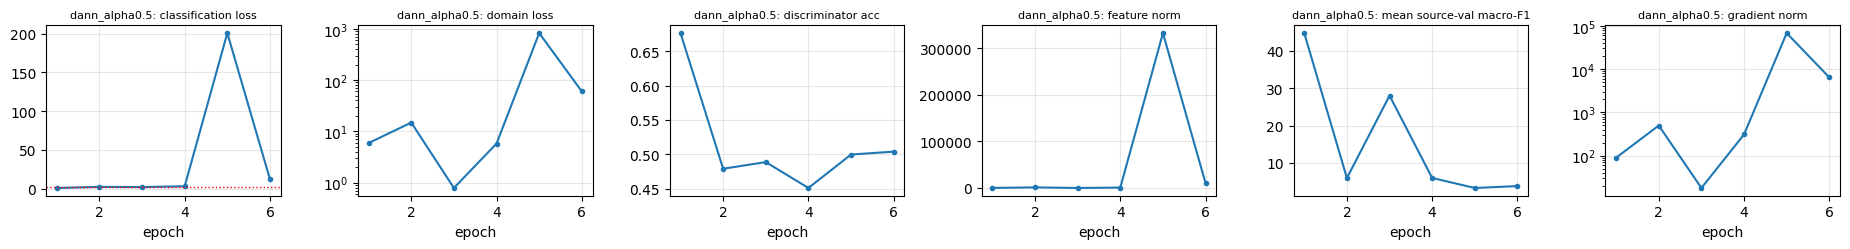

In [11]:
# B4. The second study: DANN alpha_max in {0.25, 0.5, 1} (1 is B2's dann). In the original run both blew up
# within two epochs even though the reversal weight was tiny (~0.06): expect DEGRADED / COLLAPSED again.
for config, name in [('study_dann_alpha0.25', 'dann_alpha0.25'), ('study_dann_alpha0.5', 'dann_alpha0.5')]:
    train(2, config, name)

In [12]:
# B5. All Task 2 runs, re-run vs original, on source information only.
def compare_rows(task):
    rows = []
    for r, o in ORIGINAL.items():
        if o['task'] != task or r not in summary_rows: continue
        n = summary_rows[r]
        rows.append({'run': r, 'orig_F1': o['f1'], 'rerun_F1': n['best_src_val_f1'],
                     'diff': None if o['f1'] is None else round(n['best_src_val_f1'] - o['f1'], 2),
                     'orig_epochs': o['epochs'], 'rerun_epochs': n['epochs'],
                     'orig_verdict': o['verdict'], 'rerun_verdict': n['verdict'],
                     'same_verdict': 'yes' if o['verdict'] == n['verdict'] else 'NO'})
    return pd.DataFrame(rows)
c2 = compare_rows(2); display(c2)
c2.to_csv(f'{OUT}/task2_training_rerun_vs_original.csv', index=False)
print('Healthy runs within about 1 F1 of the original and every verdict unchanged = reproducible.')
print('A changed verdict means that run sits on a knife-edge -- note it in the report.')

,run,orig_F1,rerun_F1,diff,orig_epochs,rerun_epochs,orig_verdict,rerun_verdict,same_verdict
0,source_only,94.14,94.14,0.0,20,20,STABLE,STABLE,yes
1,dan,95.02,95.02,0.0,15,15,STABLE,STABLE,yes
2,dann,35.04,35.04,0.0,23,23,COLLAPSED,COLLAPSED,yes
3,cdan,88.75,88.75,0.0,6,6,DEGRADED,DEGRADED,yes
4,dan_lambda0.1,93.90,93.90,0.0,13,13,STABLE,STABLE,yes
5,dan_lambda10,5.07,5.07,0.0,6,6,COLLAPSED,COLLAPSED,yes
6,dann_alpha0.25,88.75,88.75,0.0,6,6,DEGRADED,DEGRADED,yes
7,dann_alpha0.5,44.74,44.74,0.0,6,6,COLLAPSED,COLLAPSED,yes


Healthy runs within about 1 F1 of the original and every verdict unchanged = reproducible.
A changed verdict means that run sits on a knife-edge -- note it in the report.


## Part C - Task 2 evaluation (Sketch labels are used only here)

Main table (Source-only, DAN, DANN, CDAN), the λ study, and the α_max study: source validation, Sketch
accuracy / macro-F1, domain separability (50% = chance), per-class changes and failure grids.

In [13]:
# C1. Evaluate. Everything in Part B is fixed before this cell runs.
run('python -m task2.evaluate_final')
run('python -m task2.evaluate_final --study dan')
run('python -m task2.evaluate_final --study dann')

main2 = pd.read_csv(f'{T2_FINAL}/table_main.csv')
st_dan = pd.read_csv(f'{T2_FINAL}/table_study_dan.csv')
st_dann = pd.read_csv(f'{T2_FINAL}/table_study_dann.csv')
ev2 = pd.concat([main2, st_dan, st_dann]).drop_duplicates(subset='method').set_index('method')
display(main2.round(2))

print('\n=========== TASK 2: re-run vs original (Sketch accuracy and domain separability) ===========')
rows = []
for r, o in ORIGINAL.items():
    if o['task'] != 2 or r not in ev2.index: continue
    n = ev2.loc[r]
    rows.append({'run': r, 'orig_sketch': o['sketch'], 'rerun_sketch': round(n.target_acc, 2),
                 'diff': round(n.target_acc - o['sketch'], 2), 'orig_sep': o['sep'], 'rerun_sep': round(n.domain_sep, 2),
                 'rerun_src_F1': round(n.mean_src_f1, 2)})
c2e = pd.DataFrame(rows); display(c2e)
c2e.to_csv(f'{OUT}/task2_eval_rerun_vs_original.csv', index=False)
for f in glob.glob(f'{T2_FINAL}/*.csv') + glob.glob(f'{T2_FINAL}/*.json'):
    shutil.copy(f, f'{OUT}/task2_' + os.path.basename(f))
for f in glob.glob(f'{T2_FINAL}/figures/*.png'):
    shutil.copy(f, f'{OUT}/task2_' + os.path.basename(f))
print('\ncopied Task 2 tables and figures to', OUT, '(prefixed task2_)')

$ python -m task2.evaluate_final
     method  best_epoch  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_src_acc  mean_src_f1  target_acc  target_f1  domain_sep  delta_target_acc
source_only          15      97.31     96.78             90.73            90.74        94.46       94.90         94.16        94.14       69.59      72.41       99.86              0.00
        dan          10      96.11     95.66             92.93            93.05        95.95       96.34         94.99        95.02       58.59      55.16       82.28            -11.00
       dann          18      52.10     41.11             29.27            26.83        46.70       37.17         42.69        35.04       26.44      18.91       98.08            -43.14
       cdan           1      94.01     92.92             82.68            83.09        88.70       90.23         88.46        88.75       58.49      58.74       99.45            -11.10
  [1.4 min]
$ python -m task2.evaluate_fin

,method,best_epoch,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_src_acc,mean_src_f1,target_acc,target_f1,domain_sep,delta_target_acc
0,source_only,15,97.31,96.78,90.73,90.74,94.46,94.90,94.16,94.14,69.59,72.41,99.86,0.00
1,dan,10,96.11,95.66,92.93,93.05,95.95,96.34,94.99,95.02,58.59,55.16,82.28,-11.00
2,dann,18,52.10,41.11,29.27,26.83,46.70,37.17,42.69,35.04,26.44,18.91,98.08,-43.14
3,cdan,1,94.01,92.92,82.68,83.09,88.70,90.23,88.46,88.75,58.49,58.74,99.45,-11.10



=========== TASK 2: re-run vs original (Sketch accuracy and domain separability) ===========


,run,orig_sketch,rerun_sketch,diff,orig_sep,rerun_sep,rerun_src_F1
0,source_only,69.59,69.59,-0.0,99.86,99.86,94.14
1,dan,58.59,58.59,-0.0,82.28,82.28,95.02
2,dann,26.44,26.44,0.0,98.08,98.08,35.04
3,cdan,58.49,58.49,-0.0,99.45,99.45,88.75
4,dan_lambda0.1,67.01,67.01,0.0,97.25,97.25,93.90
5,dan_lambda10,4.07,4.07,0.0,68.27,68.27,5.07
6,dann_alpha0.25,52.30,52.30,0.0,99.73,99.73,88.75
7,dann_alpha0.5,15.47,15.47,0.0,100.00,100.00,44.74



copied Task 2 tables and figures to /kaggle/working/outputs (prefixed task2_)


## Part D - Task 3 training (no Sketch from here until Part F)

ERM is **not** trained here: it is the Source-only model from Part B, as the handout requires.
`task3/train.py` refuses to start if any protocol setting differs from that checkpoint's.

ERM = this session's Source-only: best mean source-val macro-F1 94.14

$ python -m task3.train --config task3/configs/dan_dg.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt 
Protocol matches the Task 2 Source-only checkpoint: seed=6304, num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
[dan_dg] ep01 loss_cls=1.9391 loss_mmd=0.5745 loss_total=2.5136 | val mean F1=5.07
[dan_dg] ep02 loss_cls=1.9332 loss_mmd=0.5114 loss_total=2.4447 | val mean F1=5.07
[dan_dg] ep03 loss_cls=1.9311 loss_mmd=0.4920 loss_total=2.4231 | val mean F1=5.07
[dan_dg] ep04 loss_cls=1.9247 loss_mmd=0.5211 loss_total=2.4458 | val mean F1=5.07
[dan_dg] ep05 loss_cls=1.9248 loss_mmd=0.5152 loss_total=2.4400 | val mean F1=5.07
[dan_dg] ep06 loss_cls=1.9333 loss_mmd=0.4226 loss_total=2.3559 | val mean F1=5.07
early stop at epoch 6 (best mean macro-F1 5.07)
  [2.6 min]

=== dan_dg === 

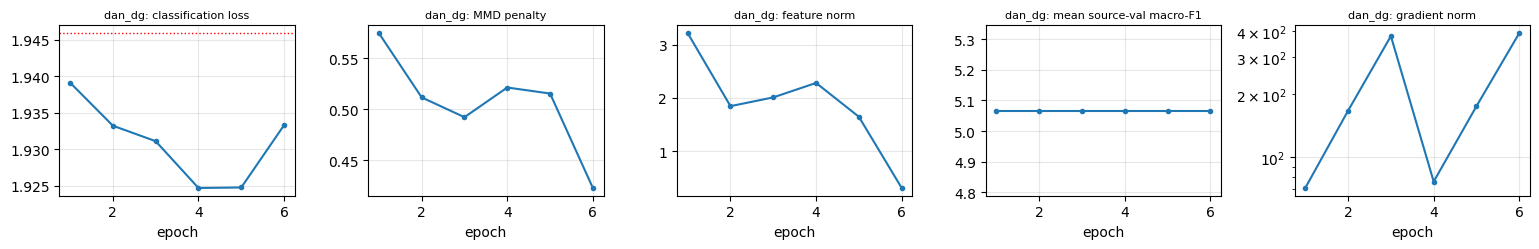

$ python -m task3.train --config task3/configs/sam.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt 
Protocol matches the Task 2 Source-only checkpoint: seed=6304, num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
[sam] ep01 loss_cls=1.0745 loss_sam=1.3571 | val mean F1=82.96
[sam] ep02 loss_cls=0.3218 loss_sam=0.5987 | val mean F1=90.19
[sam] ep03 loss_cls=0.1962 loss_sam=0.4169 | val mean F1=93.82
[sam] ep04 loss_cls=0.1396 loss_sam=0.3380 | val mean F1=93.01
[sam] ep05 loss_cls=0.1021 loss_sam=0.2668 | val mean F1=94.81
[sam] ep06 loss_cls=0.0712 loss_sam=0.2202 | val mean F1=94.91
[sam] ep07 loss_cls=0.0619 loss_sam=0.2087 | val mean F1=95.06
[sam] ep08 loss_cls=0.0480 loss_sam=0.1862 | val mean F1=94.21
[sam] ep09 loss_cls=0.0491 loss_sam=0.1821 | val mean F1=94.39
[sam] ep10 loss_cls=0.0411 loss_sam=0.1737 | val mean F1=94.25
[sam] ep11 loss_cl

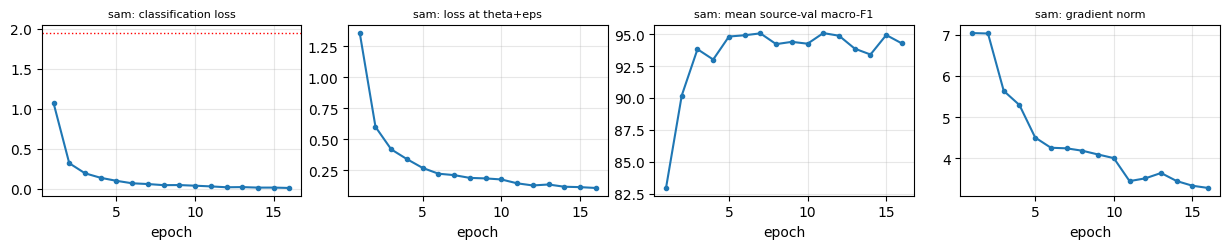

In [14]:
# D1. DAN-DG (lambda_DG = 1) and SAM (rho = 0.05): the main comparison.
#   dan_dg  expect COLLAPSED like the original (F1 5.07, loss_cls ~1.92, loss_mmd ~0.48)
#   sam     expect STABLE (~95-96), loss_sam gap above loss_cls shrinking
erm_sum = json.load(open(f'{T2_RUNS}/source_only/summary.json'))
print(f"ERM = this session's Source-only: best mean source-val macro-F1 {erm_sum['best_mean_macro_f1']:.2f}\n")
for config, name in [('dan_dg', 'dan_dg'), ('sam', 'sam')]:
    train(3, config, name)

$ python -m task3.train --config task3/configs/study_dan_dg_lambda0.1.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt 
Protocol matches the Task 2 Source-only checkpoint: seed=6304, num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
[dan_dg_lambda0.1] ep01 loss_cls=0.5633 loss_mmd=0.5916 loss_total=0.6224 | val mean F1=90.85
[dan_dg_lambda0.1] ep02 loss_cls=0.2274 loss_mmd=0.5133 loss_total=0.2788 | val mean F1=91.48
[dan_dg_lambda0.1] ep03 loss_cls=0.1553 loss_mmd=0.5032 loss_total=0.2056 | val mean F1=92.69
[dan_dg_lambda0.1] ep04 loss_cls=0.1007 loss_mmd=0.4952 loss_total=0.1502 | val mean F1=92.83
[dan_dg_lambda0.1] ep05 loss_cls=0.0767 loss_mmd=0.4797 loss_total=0.1247 | val mean F1=92.24
[dan_dg_lambda0.1] ep06 loss_cls=0.0570 loss_mmd=0.4824 loss_total=0.1053 | val mean F1=95.26
[dan_dg_lambda0.1] ep07 loss_cls=0.0577 loss_mmd=0.4720 loss_tota

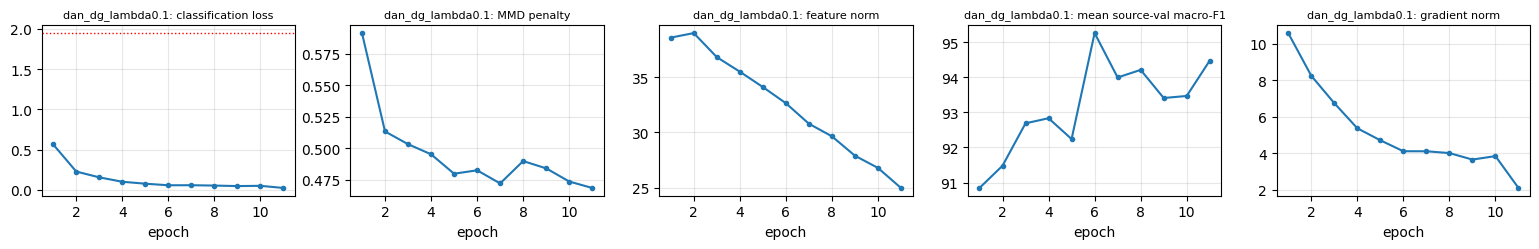

$ python -m task3.train --config task3/configs/study_dan_dg_lambda10.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt 
Protocol matches the Task 2 Source-only checkpoint: seed=6304, num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
[dan_dg_lambda10] ep01 loss_cls=1.9491 loss_mmd=0.5638 loss_total=7.5866 | val mean F1=3.61
[dan_dg_lambda10] ep02 loss_cls=1.9485 loss_mmd=0.5501 loss_total=7.4499 | val mean F1=3.61
[dan_dg_lambda10] ep03 loss_cls=1.9383 loss_mmd=0.5286 loss_total=7.2240 | val mean F1=5.07
[dan_dg_lambda10] ep04 loss_cls=1.9342 loss_mmd=0.5536 loss_total=7.4697 | val mean F1=5.07
[dan_dg_lambda10] ep05 loss_cls=1.9373 loss_mmd=0.2111 loss_total=4.0485 | val mean F1=5.07
[dan_dg_lambda10] ep06 loss_cls=1.9354 loss_mmd=0.0000 loss_total=1.9354 | val mean F1=5.07
[dan_dg_lambda10] ep07 loss_cls=1.9344 loss_mmd=0.0000 loss_total=1.9344 | val

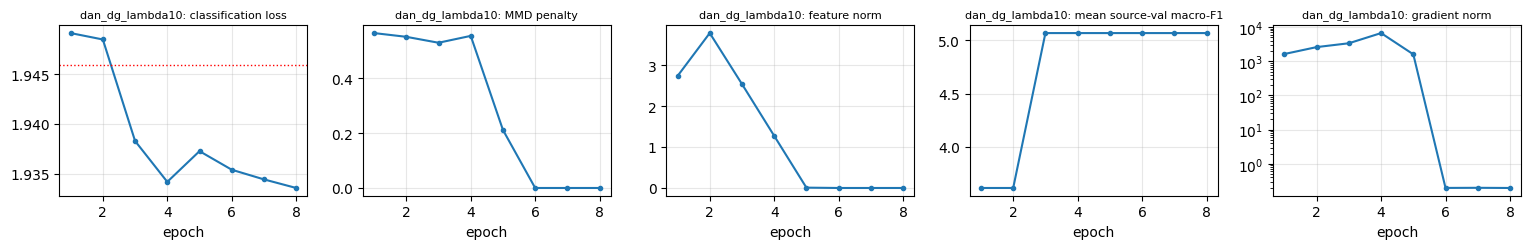

,run,orig_F1,rerun_F1,diff,orig_epochs,rerun_epochs,orig_verdict,rerun_verdict,same_verdict
0,dan_dg,5.07,5.07,0.00,6.0,6,COLLAPSED,COLLAPSED,yes
1,sam,95.60,95.08,-0.52,13.0,16,STABLE,STABLE,yes
2,dan_dg_lambda0.1,NaN,95.26,NaN,NaN,11,not finished,STABLE,NO
3,dan_dg_lambda10,NaN,5.07,NaN,NaN,8,never run,COLLAPSED,NO


In [15]:
# D2. The Task 3 controlled study: lambda_DG in {0.1, 1, 10} (1 is D1's dan_dg).
# Expect lambda = 0.1 STABLE (the CPU run reached 92 F1 in 2 epochs) and lambda = 10 COLLAPSED.
for config, name in [('study_dan_dg_lambda0.1', 'dan_dg_lambda0.1'), ('study_dan_dg_lambda10', 'dan_dg_lambda10')]:
    train(3, config, name)
c3 = compare_rows(3); display(c3)
c3.to_csv(f'{OUT}/task3_training_rerun_vs_original.csv', index=False)

## Part E - Task 3 source-side evaluation and collapse diagnosis (still no Sketch)

In [16]:
# E1. Per-domain / mean / worst source results, source-domain separability (33.3% = chance), sharpness proxy.
run(f'python -m task3.evaluate_sources {T3_EVAL}')
run(f'python -m task3.evaluate_sources --study dan_dg {T3_EVAL}')
ss = pd.read_csv(f'{T3_FINAL}/source_side.csv')
display(ss.round(3))
for _, r in ss.iterrows():
    print(f'  {r.method:10s} mean {r.mean_acc:6.2f}% | worst {r.worst_acc:6.2f}% '
          f'| source separability {r.src_domain_sep:6.2f}% | sharpness {r.sharpness:+.4f}')

$ python -m task3.evaluate_sources --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt
method  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_acc  mean_f1  worst_acc  worst_f1  src_domain_sep  sharpness  val_batch_loss  grad_norm
   erm     97.305    96.782            90.732           90.737       94.456      94.899    94.164   94.139     90.732    90.737          87.708      0.286           0.192      5.767
dan_dg     25.749     5.850            21.951            5.143       17.271       4.208    21.657    5.067     17.271     4.208          48.505      0.040           1.934      2.706
   sam     98.503    98.181            91.220           90.979       95.736      96.077    95.153   95.079     91.220    90.979          87.375      0.110           0.093      2.136
  [0.7 min]
$ python -m task3.evaluate_sources --study dan_dg --set data_root=/kaggle/input/datasets/talhaimran27

,method,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_acc,mean_f1,worst_acc,worst_f1,src_domain_sep,sharpness,val_batch_loss,grad_norm
0,erm,97.305,96.782,90.732,90.737,94.456,94.899,94.164,94.139,90.732,90.737,87.708,0.286,0.192,5.767
1,dan_dg,25.749,5.850,21.951,5.143,17.271,4.208,21.657,5.067,17.271,4.208,48.505,0.040,1.934,2.706
2,sam,98.503,98.181,91.220,90.979,95.736,96.077,95.153,95.079,91.220,90.979,87.375,0.110,0.093,2.136


  erm        mean  94.16% | worst  90.73% | source separability  87.71% | sharpness +0.2856
  dan_dg     mean  21.66% | worst  17.27% | source separability  48.50% | sharpness +0.0399
  sam        mean  95.15% | worst  91.22% | source separability  87.38% | sharpness +0.1097


In [17]:
# E2. Why did DAN-DG collapse? Source validation only.
run(f'python -m task3.diagnose_collapse {T3_EVAL}')
cd = pd.read_csv(f'{T3_FINAL}/collapse_diagnostics.csv')
display(cd.round(3))
print('''How to read it
  top_pred_share ~100%      one class for everything (the head collapsed)
  class_probe high (>80%)   the FEATURES still separate the classes -> the head never learned to read them
  class_probe near 14.3%    the backbone itself erased class information
  feat_norm far below ERM   supports the shrinking explanation (biased-MMD pull)
  mmd_biased - floor        the part of the logged MMD that is a real domain difference''')
for f in glob.glob(f'{T3_FINAL}/*.csv') + glob.glob(f'{T3_FINAL}/*.json'):
    shutil.copy(f, f'{OUT}/task3_' + os.path.basename(f))

$ python -m task3.diagnose_collapse --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt
  erm                    F1  94.14 | predicts 'person' for  20.0% | |F(x)|  69.650 | class probe  93.8% | domain sep  87.7% | MMD 8v8 biased 0.629 (floor 0.433) unbiased +0.1972
  sam                    F1  95.08 | predicts 'person' for  21.4% | |F(x)|  43.203 | class probe  94.5% | domain sep  87.4% | MMD 8v8 biased 0.600 (floor 0.441) unbiased +0.1645
  dan_dg_lambda0.1       F1  95.26 | predicts 'person' for  20.4% | |F(x)|  31.843 | class probe  94.0% | domain sep  79.1% | MMD 8v8 biased 0.477 (floor 0.446) unbiased +0.0285
  dan_dg                 F1   5.07 | predicts 'person' for 100.0% | |F(x)|   1.774 | class probe  28.5% | domain sep  48.5% | MMD 8v8 biased 0.483 (floor 0.450) unbiased +0.0332
  dan_dg_lambda10        F1   5.07 | predicts 'person' for 100.0% | |F(x)|   2.389 | class probe  25.1% | domain sep  45.8% | MM

,run,ckpt_epoch,mean_f1,top_pred,top_pred_share,feat_norm,class_probe,domain_sep,mmd_biased_8v8,mmd_unbiased_8v8,floor_biased_8v8
0,erm,15,94.139,person,20.033,69.650,93.826,87.708,0.629,0.197,0.433
1,sam,11,95.079,person,21.434,43.203,94.527,87.375,0.600,0.164,0.441
2,dan_dg_lambda0.1,6,95.255,person,20.363,31.843,93.984,79.070,0.477,0.029,0.446
3,dan_dg,1,5.067,person,100.000,1.774,28.519,48.505,0.483,0.033,0.450
4,dan_dg_lambda10,3,5.067,person,100.000,2.389,25.109,45.847,0.729,0.330,0.408


How to read it
  top_pred_share ~100%      one class for everything (the head collapsed)
  class_probe high (>80%)   the FEATURES still separate the classes -> the head never learned to read them
  class_probe near 14.3%    the backbone itself erased class information
  feat_norm far below ERM   supports the shrinking explanation (biased-MMD pull)
  mmd_biased - floor        the part of the logged MMD that is a real domain difference


## Part F - Task 3 Sketch evaluation (the only Sketch access in Task 3)

In [18]:
# F1. Main comparison, the lambda_DG study, per-class changes and the Task 2 vs Task 3 comparison (RQ4).
# The Task 2 side of RQ4 is this session's Part C, so both tasks come from the same re-run.
run(f'python -m task3.evaluate_sketch {T3_EVAL}')
run(f'python -m task3.evaluate_sketch --study dan_dg {T3_EVAL}')
main3 = pd.read_csv(f'{T3_FINAL}/table_main.csv')
display(main3.round(2))
erm_row = main3[main3.method == 'erm'].iloc[0]
for _, r in main3.iterrows():
    tag = 'baseline' if r.method == 'erm' else f'{r.sketch_acc - erm_row.sketch_acc:+.2f} pts vs ERM'
    print(f'  {r.method:10s} source mean {r.mean_f1:6.2f} F1 / worst {r.worst_f1:6.2f} | Sketch {r.sketch_acc:6.2f}% '
          f'| src-sep {r.src_domain_sep:6.2f}% | sharpness {r.sharpness:+.4f}   ({tag})')
st3 = pd.read_csv(f'{T3_FINAL}/table_study_dan_dg.csv')
display(st3.round(3))
print('\nThe main comparison keeps lambda_DG = 1 whatever the study shows.')
print('\n=== RQ4 ==='); print(open(f'{T3_FINAL}/task2_vs_task3_overall.json').read())
for f in glob.glob(f'{T3_FINAL}/*.csv') + glob.glob(f'{T3_FINAL}/*.json'):
    shutil.copy(f, f'{OUT}/task3_' + os.path.basename(f))
for f in glob.glob(f'{T3_FINAL}/figures/*.png'):
    shutil.copy(f, f'{OUT}/task3_' + os.path.basename(f))

$ python -m task3.evaluate_sketch --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt
/kaggle/working/PA1/task2/evaluation/class_analysis.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=.3); ax.legend(fontsize=7)
method  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_acc  mean_f1  worst_acc  worst_f1  src_domain_sep  sharpness  val_batch_loss  grad_norm  sketch_acc  sketch_f1  delta_sketch_acc_vs_erm
   erm     97.305    96.782            90.732           90.737       94.456      94.899    94.164   94.139     90.732    90.737          87.708      0.286           0.192      5.767      69.585     72.412                    0.000
dan_dg     25.749     5.850            21.951            5.143       

,method,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_acc,mean_f1,worst_acc,worst_f1,src_domain_sep,sharpness,val_batch_loss,grad_norm,sketch_acc,sketch_f1,delta_sketch_acc_vs_erm
0,erm,97.31,96.78,90.73,90.74,94.46,94.90,94.16,94.14,90.73,90.74,87.71,0.29,0.19,5.77,69.59,72.41,0.00
1,dan_dg,25.75,5.85,21.95,5.14,17.27,4.21,21.66,5.07,17.27,4.21,48.50,0.04,1.93,2.71,4.07,1.12,-65.51
2,sam,98.50,98.18,91.22,90.98,95.74,96.08,95.15,95.08,91.22,90.98,87.38,0.11,0.09,2.14,68.08,72.25,-1.50


  erm        source mean  94.14 F1 / worst  90.74 | Sketch  69.59% | src-sep  87.71% | sharpness +0.2856   (baseline)
  dan_dg     source mean   5.07 F1 / worst   4.21 | Sketch   4.07% | src-sep  48.50% | sharpness +0.0399   (-65.51 pts vs ERM)
  sam        source mean  95.08 F1 / worst  90.98 | Sketch  68.08% | src-sep  87.38% | sharpness +0.1097   (-1.50 pts vs ERM)


,setting,method,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_acc,mean_f1,worst_acc,worst_f1,src_domain_sep,sharpness,val_batch_loss,grad_norm,sketch_acc,sketch_f1,delta_sketch_acc_vs_dan_dg
0,lambda=0.1,dan_dg_lambda0.1,97.305,96.745,92.927,93.315,95.309,95.705,95.180,95.255,92.927,93.315,79.070,0.174,0.119,4.007,68.160,71.119,64.088
1,lambda=1,dan_dg,25.749,5.850,21.951,5.143,17.271,4.208,21.657,5.067,17.271,4.208,48.505,0.040,1.934,2.706,4.072,1.118,0.000
2,lambda=10,dan_dg_lambda10,25.749,5.850,21.951,5.143,17.271,4.208,21.657,5.067,17.271,4.208,45.847,0.007,1.933,0.459,4.072,1.118,0.000



The main comparison keeps lambda_DG = 1 whatever the study shows.

=== RQ4 ===
{
  "ERM": 69.58513616696361,
  "DAN_task2": 58.58997200305421,
  "DAN_DG_task3": 4.0722830236701455
}


## Part G - did anything change from run to run? Then save.

In [19]:
# G1. Every run: original vs re-run.
allc = pd.concat([compare_rows(2).assign(task=2), compare_rows(3).assign(task=3)])
display(allc)
allc.to_csv(f'{OUT}/rerun_vs_original_all.csv', index=False)
changed = allc[allc.same_verdict == 'NO']
healthy = allc[(allc.rerun_verdict == 'STABLE') & allc['diff'].notna()]
print(f'\nVerdicts unchanged: {int((allc.same_verdict == "yes").sum())} of {len(allc)} runs'
      f'  (runs never finished originally count as changed: {list(allc[allc.orig_F1.isna()].run)})')
if len(healthy):
    print(f'Healthy runs: largest source-F1 difference from the original = {healthy["diff"].abs().max():.2f} points')
real = changed[changed.orig_F1.notna()]
if len(real):
    print('\nRUNS WHOSE VERDICT CHANGED (knife-edge -- report them):')
    for _, r in real.iterrows():
        print(f'  {r.run:18s} {r.orig_verdict} (F1 {r.orig_F1}) -> {r.rerun_verdict} (F1 {r.rerun_F1})')
else:
    print('\nNo finished run changed verdict: the collapses are reproducible, not session flukes.')

,run,orig_F1,rerun_F1,diff,orig_epochs,rerun_epochs,orig_verdict,rerun_verdict,same_verdict,task
0,source_only,94.14,94.14,0.00,20.0,20,STABLE,STABLE,yes,2
1,dan,95.02,95.02,0.00,15.0,15,STABLE,STABLE,yes,2
2,dann,35.04,35.04,0.00,23.0,23,COLLAPSED,COLLAPSED,yes,2
3,cdan,88.75,88.75,0.00,6.0,6,DEGRADED,DEGRADED,yes,2
4,dan_lambda0.1,93.90,93.90,0.00,13.0,13,STABLE,STABLE,yes,2
5,dan_lambda10,5.07,5.07,0.00,6.0,6,COLLAPSED,COLLAPSED,yes,2
6,dann_alpha0.25,88.75,88.75,0.00,6.0,6,DEGRADED,DEGRADED,yes,2
7,dann_alpha0.5,44.74,44.74,0.00,6.0,6,COLLAPSED,COLLAPSED,yes,2
0,dan_dg,5.07,5.07,0.00,6.0,6,COLLAPSED,COLLAPSED,yes,3
1,sam,95.60,95.08,-0.52,13.0,16,STABLE,STABLE,yes,3



Verdicts unchanged: 10 of 12 runs  (runs never finished originally count as changed: ['dan_dg_lambda0.1', 'dan_dg_lambda10'])
Healthy runs: largest source-F1 difference from the original = 0.52 points

No finished run changed verdict: the collapses are reproducible, not session flukes.


In [20]:
# G2. Save. The Task 2 folders are exported as runs_rerun / final_rerun so they cannot overwrite the original
# runs_clip0.0 / final_clip0.0 in your GitHub repo. Task 3 keeps its default folder names (its scripts use them).
def export(tag):
    stage = f'/kaggle/working/export_{tag}'
    if os.path.isdir(stage): shutil.rmtree(stage)
    for z in ['rerun_light.zip', 'rerun_full.zip']:          # rebuilt from scratch each time
        if os.path.exists(f'{OUT}/{z}'): os.remove(f'{OUT}/{z}')
    for src_dir, dst in [(T2_RUNS, 'task2/results/runs_rerun'), (T2_FINAL, 'task2/results/final_rerun'),
                         (T3_RUNS, 'task3/results/runs'), (T3_FINAL, 'task3/results/final')]:
        if os.path.isdir(src_dir):
            shutil.copytree(src_dir, f'{stage}/{dst}')
    os.system(f'cd {stage} && zip -qr {OUT}/rerun_light.zip . -x "*.pt"')     # tables, histories, figures
    os.system(f'cd {stage} && zip -qr {OUT}/rerun_full.zip .')                # + checkpoints (large)
    shutil.rmtree(stage)
export('main')
for f in sorted(os.listdir(OUT)):
    print(f'{os.path.getsize(f"{OUT}/{f}")/1e6:8.2f} MB  outputs/{f}')
print('\nDownload rerun_light.zip + the CSVs; rerun_full.zip only if you want the checkpoints.')

    0.08 MB  outputs/curves_cdan.png
    0.06 MB  outputs/curves_dan.png
    0.07 MB  outputs/curves_dan_dg.png
    0.07 MB  outputs/curves_dan_dg_lambda0.1.png
    0.06 MB  outputs/curves_dan_dg_lambda10.png
    0.06 MB  outputs/curves_dan_lambda0.1.png
    0.06 MB  outputs/curves_dan_lambda10.png
    0.09 MB  outputs/curves_dann.png
    0.08 MB  outputs/curves_dann_alpha0.25.png
    0.09 MB  outputs/curves_dann_alpha0.5.png
    0.06 MB  outputs/curves_sam.png
    0.05 MB  outputs/curves_source_only.png
  504.43 MB  outputs/rerun_full.zip
    1.22 MB  outputs/rerun_light.zip
    0.00 MB  outputs/rerun_vs_original_all.csv
    0.01 MB  outputs/task2_class_analysis.json
    0.00 MB  outputs/task2_eval_rerun_vs_original.csv
    0.12 MB  outputs/task2_failures_cdan_dog.png
    0.10 MB  outputs/task2_failures_dan_person.png
    0.11 MB  outputs/task2_failures_dann_guitar.png
    0.12 MB  outputs/task2_failures_source_only_giraffe.png
    0.00 MB  outputs/task2_frozen_dan.json
    0.00 MB  o

## Part H1 - seed check (robustness, not a comparison)

The two MMD collapses are repeated with **seed 6305**. That changes the head's initialisation, the
sampling order and the augmentation; the splits stay fixed. If they collapse again, the collapse does not
depend on seed 6304. Neither run is ever evaluated on Sketch or used in any table of the main comparison.

$ python -m task2.train --config task2/configs/study_dan_lambda10.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS seed=6305 run_name=dan_lambda10_seed6305
[dan_lambda10_seed6305] ep01 loss_cls=1.9417 loss_mmd=0.2593 loss_total=4.5345 | val mean F1=3.31
[dan_lambda10_seed6305] ep02 loss_cls=1.9405 loss_mmd=0.2151 loss_total=4.0917 | val mean F1=3.82
[dan_lambda10_seed6305] ep03 loss_cls=1.9347 loss_mmd=0.2126 loss_total=4.0611 | val mean F1=5.07
[dan_lambda10_seed6305] ep04 loss_cls=1.9319 loss_mmd=0.2149 loss_total=4.0812 | val mean F1=5.07
[dan_lambda10_seed6305] ep05 loss_cls=1.9275 loss_mmd=0.2097 loss_total=4.0248 | val mean F1=5.07
[dan_lambda10_seed6305] ep06 loss_cls=1.9235 loss_mmd=0.2132 loss_total=4.0551 | val mean F1=5.07
[dan_lambda10_seed6305] ep07 loss_cls=1.9448 loss_mmd=0.1962 loss_total=3.9063 | val mean F1=5.07
[dan_lambda10_seed6305] ep08 loss_cls=1.9185 loss_mmd=0.2056 loss_total=3.9745 | val mean F1=5.07
early stop at epoch 8 (best mean m

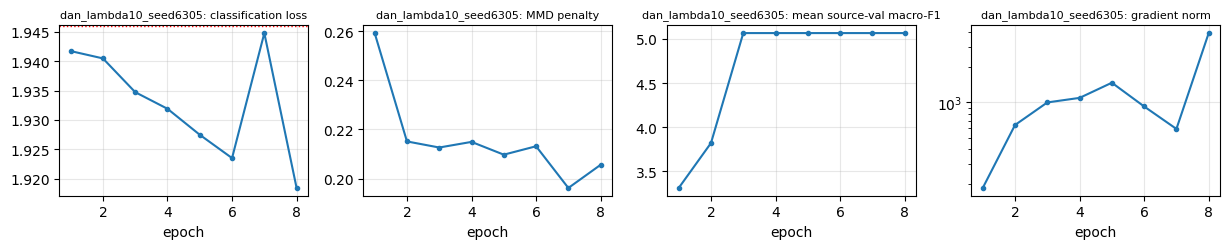

$ python -m task3.train --config task3/configs/dan_dg.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt seed=6305 run_name=dan_dg_seed6305 seed_check=true
SEED CHECK: seed 6305 differs from the ERM checkpoint's seed 6304 on purpose. Robustness run -- not part of any comparison.
Protocol matches the Task 2 Source-only checkpoint: num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
[dan_dg_seed6305] ep01 loss_cls=1.9313 loss_mmd=0.5683 loss_total=2.4996 | val mean F1=3.31
[dan_dg_seed6305] ep02 loss_cls=1.9421 loss_mmd=0.5201 loss_total=2.4622 | val mean F1=5.07
[dan_dg_seed6305] ep03 loss_cls=1.9766 loss_mmd=0.5475 loss_total=2.5242 | val mean F1=5.07
[dan_dg_seed6305] ep04 loss_cls=1.9411 loss_mmd=0.1026 loss_total=2.0437 | val mean F1=5.07
[dan_dg_seed6305] ep05 loss_cls=1.9398 loss_mmd=0.0000 loss_total=1.9398 | val mean F1=5.07
[dan_dg_seed6305] ep06

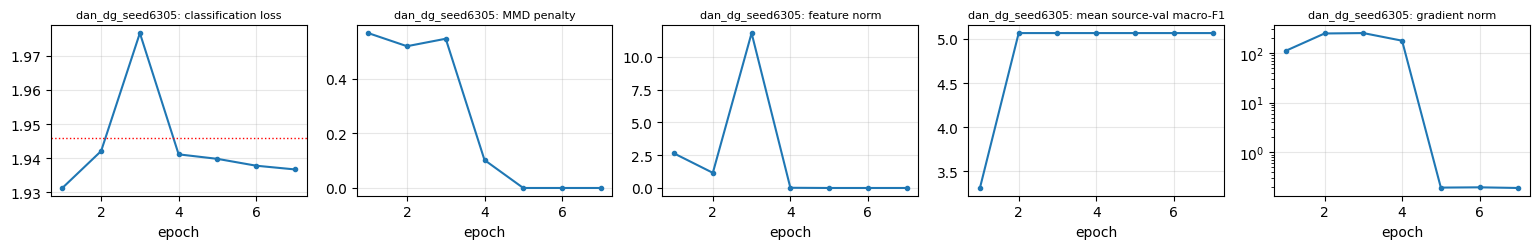

,run,seed 6304 F1,seed 6304 verdict,seed 6305 F1,seed 6305 verdict,same
0,dan_lambda10,5.07,COLLAPSED,5.07,COLLAPSED,yes
1,dan_dg,5.07,COLLAPSED,5.07,COLLAPSED,yes


same = yes: the collapse does not depend on the seed.  same = NO: it does -- report that.


In [21]:
# H1. Seed check.
SEED_CHECK = True               # set to False to skip
CHECK_SEED = 6305
SEED_RUNS = [(2, 'study_dan_lambda10', 'dan_lambda10'),    # Task 2 MMD collapse
             (3, 'dan_dg', 'dan_dg')]                       # Task 3 MMD collapse (lambda_DG = 1)
if not SEED_CHECK:
    print('Skipped (SEED_CHECK = False).')
else:
    rows = []
    for task, config, base in SEED_RUNS:
        name = f'{base}_seed{CHECK_SEED}'
        extra = f'seed={CHECK_SEED} run_name={name}' + (' seed_check=true' if task == 3 else '')
        train(task, config, name, extra)
        a, b = summary_rows[base], summary_rows[name]
        rows.append({'run': base, 'seed 6304 F1': a['best_src_val_f1'], 'seed 6304 verdict': a['verdict'],
                     f'seed {CHECK_SEED} F1': b['best_src_val_f1'], f'seed {CHECK_SEED} verdict': b['verdict'],
                     'same': 'yes' if a['verdict'] == b['verdict'] else 'NO'})
    sc = pd.DataFrame(rows); display(sc)
    sc.to_csv(f'{OUT}/seed_check.csv', index=False)
    print('same = yes: the collapse does not depend on the seed.  same = NO: it does -- report that.')
    export('seed')

## Part H2 - the estimator switch (diagnostic, last on purpose)

DAN-DG again at **λ_DG = 1**, with the same kernels, bandwidth, batches and protocol. Only the MMD estimator
changes: **unbiased**, so no self-comparisons, no ~0.47 floor and no pull that keeps shrinking the features.
It runs after the Task 3 Sketch evaluation, so the main comparison is already locked with the biased
estimator. Report this as a diagnostic only. It is never evaluated on Sketch.

| If the unbiased run... | it means |
|---|---|
| trains (source F1 around 90, `loss_cls` well below 1.9) | the biased estimator's small-sample pull is the most likely cause of the collapse |
| collapses the same way (F1 about 5, `loss_cls` about 1.92) | the estimator is not the cause; the MMD gradient at 8 vs 8 is too strong or noisy either way |

$ python -m task3.train --config task3/configs/diag_dan_dg_unbiased.yaml --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt 
Protocol matches the Task 2 Source-only checkpoint: seed=6304, num_workers=2, per_domain_batch=8, lr=0.0001, weight_decay=0.0001, grad_clip=0.0, max_epochs=30, patience=5
NOTE: DAN-DG is using the UNBIASED MMD estimator -- diagnostic run, not the main result.
[diag_dan_dg_unbiased] ep01 loss_cls=0.5430 loss_mmd=0.0567 loss_total=0.5997 | val mean F1=88.92
[diag_dan_dg_unbiased] ep02 loss_cls=0.2327 loss_mmd=0.0291 loss_total=0.2618 | val mean F1=92.56
[diag_dan_dg_unbiased] ep03 loss_cls=0.1803 loss_mmd=0.0273 loss_total=0.2076 | val mean F1=92.17
[diag_dan_dg_unbiased] ep04 loss_cls=0.1418 loss_mmd=0.0253 loss_total=0.1671 | val mean F1=93.27
[diag_dan_dg_unbiased] ep05 loss_cls=0.1154 loss_mmd=0.0146 loss_total=0.1300 | val mean F1=93.72
[diag_dan_dg_unbiased] ep06 loss_cls=0.1113 loss_mmd

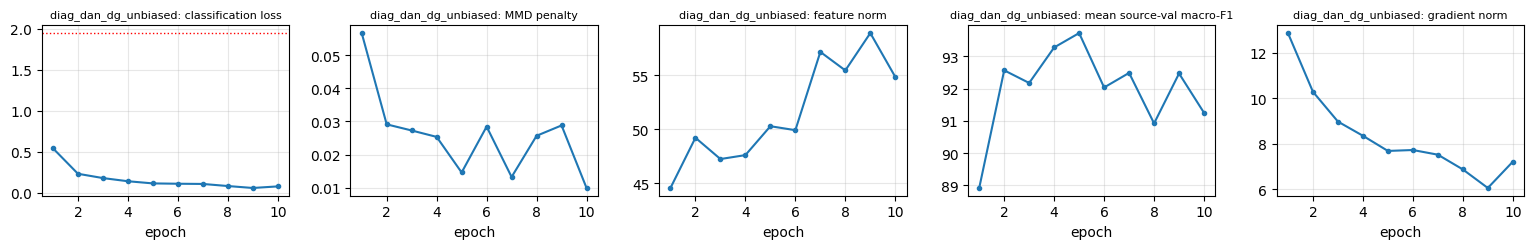

$ python -m task3.diagnose_collapse --set data_root=/kaggle/input/datasets/talhaimran27/pacs-dataset/PACS erm_checkpoint=task2/results/runs/source_only/best.pt
  erm                    F1  94.14 | predicts 'person' for  20.0% | |F(x)|  69.650 | class probe  93.8% | domain sep  87.7% | MMD 8v8 biased 0.629 (floor 0.433) unbiased +0.1972
  sam                    F1  95.08 | predicts 'person' for  21.4% | |F(x)|  43.203 | class probe  94.5% | domain sep  87.4% | MMD 8v8 biased 0.600 (floor 0.441) unbiased +0.1645
  dan_dg_lambda0.1       F1  95.26 | predicts 'person' for  20.4% | |F(x)|  31.843 | class probe  94.0% | domain sep  79.1% | MMD 8v8 biased 0.477 (floor 0.446) unbiased +0.0285
  dan_dg                 F1   5.07 | predicts 'person' for 100.0% | |F(x)|   1.774 | class probe  28.5% | domain sep  48.5% | MMD 8v8 biased 0.483 (floor 0.450) unbiased +0.0332
  dan_dg_lambda10        F1   5.07 | predicts 'person' for 100.0% | |F(x)|   2.389 | class probe  25.1% | domain sep  45.8% | MM

,ckpt_epoch,mean_f1,top_pred,top_pred_share,feat_norm,class_probe,domain_sep,mmd_biased_8v8,mmd_unbiased_8v8,floor_biased_8v8
run,,,,,,,,,,
erm,15,94.139,person,20.033,69.650,93.826,87.708,0.629,0.197,0.433
sam,11,95.079,person,21.434,43.203,94.527,87.375,0.600,0.164,0.441
dan_dg_lambda0.1,6,95.255,person,20.363,31.843,93.984,79.070,0.477,0.029,0.446
dan_dg,1,5.067,person,100.000,1.774,28.519,48.505,0.483,0.033,0.450
dan_dg_lambda10,3,5.067,person,100.000,2.389,25.109,45.847,0.729,0.330,0.408
diag_dan_dg_unbiased,5,93.718,person,22.424,47.597,93.838,71.429,0.501,0.026,0.471



============ lambda_DG = 1: biased (main) vs unbiased (diagnostic) ============
                                                     biased/main   unbiased/diag
  best mean source-val macro-F1                             5.07           93.72
  epochs run                                                   6              10
  lowest loss_cls (1.913 = no class info)                  1.925           0.060
  last loss_mmd (biased floor ~0.47; unbiased ~0)          0.423           0.010
  first -> last feature norm (biased run)                  3.221           0.304
  first -> last feature norm (unbiased run)               44.570          54.821
  max gradient norm                                          392            12.9
  class probe on frozen features (%, 14.3 = chance)          28.5            93.8
  share of images given the top class (%)                  100.0            22.4
  source-domain separability (%, 33.3 = chance)             48.5            71.4

WHAT IT MEANS
  The unbias

In [22]:
# H2. LAST CELL -- the estimator switch, as a labelled DIAGNOSTIC. Everything above is already saved.
RUN_UNBIASED_DIAG = True        # set to False to skip
DIAG = 'diag_dan_dg_unbiased'
if not RUN_UNBIASED_DIAG:
    print('Skipped (RUN_UNBIASED_DIAG = False).')
else:
    train(3, DIAG, DIAG)
    run(f'python -m task3.diagnose_collapse {T3_EVAL}')   # the table now includes the diagnostic run
    cd = pd.read_csv(f'{T3_FINAL}/collapse_diagnostics.csv').set_index('run')
    display(cd.round(3))

    hb, hu = [json.load(open(f'{T3_RUNS}/{r}/history.json')) for r in ('dan_dg', DIAG)]
    sb, su = [json.load(open(f'{T3_RUNS}/{r}/summary.json')) for r in ('dan_dg', DIAG)]
    def line(label, a, b, fmt='{:.3f}'):
        print(f'  {label:48s}{fmt.format(a):>14s}{fmt.format(b):>16s}')
    print('\n============ lambda_DG = 1: biased (main) vs unbiased (diagnostic) ============')
    print(f'  {"":48s}{"biased/main":>14s}{"unbiased/diag":>16s}')
    line('best mean source-val macro-F1', sb['best_mean_macro_f1'], su['best_mean_macro_f1'], '{:.2f}')
    line('epochs run', sb['epochs_run'], su['epochs_run'], '{:d}')
    line('lowest loss_cls (1.913 = no class info)', min(h['loss_cls'] for h in hb), min(h['loss_cls'] for h in hu))
    line('last loss_mmd (biased floor ~0.47; unbiased ~0)', hb[-1]['loss_mmd'], hu[-1]['loss_mmd'])
    line('first -> last feature norm (biased run)', hb[0]['feat_norm'], hb[-1]['feat_norm'])
    line('first -> last feature norm (unbiased run)', hu[0]['feat_norm'], hu[-1]['feat_norm'])
    line('max gradient norm', max(h['grad_norm'] for h in hb), max(h['grad_norm'] for h in hu), '{:.3g}')
    if {'dan_dg', DIAG} <= set(cd.index):
        line('class probe on frozen features (%, 14.3 = chance)', cd.loc['dan_dg', 'class_probe'], cd.loc[DIAG, 'class_probe'], '{:.1f}')
        line('share of images given the top class (%)', cd.loc['dan_dg', 'top_pred_share'], cd.loc[DIAG, 'top_pred_share'], '{:.1f}')
        line('source-domain separability (%, 33.3 = chance)', cd.loc['dan_dg', 'domain_sep'], cd.loc[DIAG, 'domain_sep'], '{:.1f}')

    f1u = su['best_mean_macro_f1']
    print('\nWHAT IT MEANS')
    if f1u >= 80:
        print("  The unbiased run TRAINED: the biased estimator's small-sample pull is the most likely cause of the")
        print('  lambda = 1 collapse. The main DAN-DG row stays the biased run; report this as a diagnostic.')
    elif f1u < 50:
        print('  The unbiased run ALSO COLLAPSED: the estimator is not the cause. The MMD gradient from 8-vs-8')
        print('  estimates overwhelms classification either way. Keep the biased results and report this.')
    else:
        print("  IN BETWEEN: it learned something but not well. Send this cell's output to Claude.")
    shutil.copy(f'{T3_FINAL}/collapse_diagnostics.csv', f'{OUT}/task3_collapse_diagnostics.csv')
    export('final')
    print('\nre-saved: the zips now include every run, the seed check and this diagnostic.')

In [24]:
!cd /kaggle/working/outputs && mkdir -p rerun_check && \
 cp curves_*.png rerun_vs_original_all.csv seed_check.csv task2_eval_rerun_vs_original.csv training_summary.csv rerun_check/ && \
 rm -f rerun_check.zip && zip -qr rerun_check.zip rerun_check && unzip -l rerun_check.zip | tail -1

  1023252                     20 files


In [25]:
# X1. Paired significance tests on Sketch -- EVALUATION ONLY: fixed checkpoints, nothing trained or chosen.
# What a strict reader will ask for:
#   (1) every reported model's per-image Sketch predictions, so any comparison can be re-checked later;
#   (2) whether each accuracy difference is bigger than test-set noise: McNemar's exact test on the images
#       where exactly one of the two models is right, a 95% CI for the paired difference, and a Holm
#       correction because many comparisons are tested at once.
# It does NOT measure training randomness (other seeds) -- that stays a stated limitation.
# Diagnostic and seed-check runs are left out on purpose: they are never evaluated on Sketch.
import numpy as np, pandas as pd, torch
from scipy.stats import binomtest
from shared.diagnostics import extract
from shared.models import ResNet18Classifier
from shared.pacs import CLASSES
from shared.pacs_protocol import load_target_items

MODELS = {'ERM (T2 source_only)': f'{T2_RUNS}/source_only/best.pt',
          'T2 DAN':               f'{T2_RUNS}/dan/best.pt',
          'T2 DANN':              f'{T2_RUNS}/dann/best.pt',
          'T2 CDAN':              f'{T2_RUNS}/cdan/best.pt',
          'T2 DAN l=0.1':         f'{T2_RUNS}/dan_lambda0.1/best.pt',
          'T2 DAN l=10':          f'{T2_RUNS}/dan_lambda10/best.pt',
          'T3 SAM':               f'{T3_RUNS}/sam/best.pt',
          'T3 DAN-DG':            f'{T3_RUNS}/dan_dg/best.pt',
          'T3 DAN-DG l=0.1':      f'{T3_RUNS}/dan_dg_lambda0.1/best.pt',
          'T3 DAN-DG l=10':       f'{T3_RUNS}/dan_dg_lambda10/best.pt'}
target = load_target_items()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
preds, y = {}, None
for name, path in MODELS.items():
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m = ResNet18Classifier(num_classes=len(CLASSES), pretrained=False)
    m.load_state_dict(ck['model']); m = m.to(device).eval()
    _, z, yy = extract(m, PACS, target, device)
    if y is None:
        y = yy
    assert (yy == y).all()
    preds[name] = z.argmax(1)
    print(f'  {name:22s} Sketch acc {100 * (preds[name] == y).mean():6.2f}%   (must match the tables above)')
    del m, ck
    torch.cuda.empty_cache()

pd.DataFrame({'image': [it[0] for it in target], 'label': [CLASSES[k] for k in y],
              **{k: [CLASSES[p] for p in v] for k, v in preds.items()}}).to_csv(f'{OUT}/sketch_predictions.csv', index=False)

PAIRS = [  # (baseline, method, what it answers)
    ('ERM (T2 source_only)', 'T2 DAN',          'T2 main table'),
    ('ERM (T2 source_only)', 'T2 DANN',         'T2 main table'),
    ('ERM (T2 source_only)', 'T2 CDAN',         'T2 main table'),
    ('T2 DANN',              'T2 CDAN',         'T2 RQ3: conditional vs marginal adversarial'),
    ('ERM (T2 source_only)', 'T2 DAN l=0.1',    'T2 study'),
    ('T2 DAN l=0.1',         'T2 DAN',          'T2 study: lambda 0.1 -> 1'),
    ('ERM (T2 source_only)', 'T3 SAM',          'T3 main table'),
    ('ERM (T2 source_only)', 'T3 DAN-DG',       'T3 main table'),
    ('ERM (T2 source_only)', 'T3 DAN-DG l=0.1', 'T3 study'),
    ('T3 SAM',               'T3 DAN-DG l=0.1', 'T3: SAM vs the working DAN-DG'),
    ('T3 DAN-DG l=0.1',      'T2 DAN l=0.1',    'RQ4 at lambda 0.1: does seeing Sketch help?'),
    ('T3 DAN-DG',            'T2 DAN',          'RQ4 at lambda 1 (DAN-DG collapsed)'),
]

def holm(p):
    p = np.asarray(p, dtype=float); order = np.argsort(p); adj = np.empty_like(p); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

rows, per_class = [], {}
for a, b, q in PAIRS:
    ca, cb = preds[a] == y, preds[b] == y
    only_a, only_b = int((ca & ~cb).sum()), int((~ca & cb).sum())
    d = cb.astype(float) - ca.astype(float)
    diff, se = 100 * d.mean(), 100 * d.std(ddof=1) / np.sqrt(len(d))
    p = binomtest(only_b, only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
    rows.append({'comparison': f'{b}  vs  {a}', 'question': q, 'delta_acc_pts': round(diff, 2),
                 'ci95_low': round(diff - 1.96 * se, 2), 'ci95_high': round(diff + 1.96 * se, 2),
                 'only_baseline_right': only_a, 'only_method_right': only_b, 'mcnemar_p': p})
    per_class[f'{b} vs {a}'] = {CLASSES[k]: int(cb[y == k].sum() - ca[y == k].sum()) for k in range(len(CLASSES))}
sig = pd.DataFrame(rows)
sig['p_holm'] = holm(sig.mcnemar_p)
sig['verdict'] = np.where(sig.p_holm < 0.05, 'real (beyond test-set noise)', 'NOT distinguishable from noise')
pd.set_option('display.width', 220)
display(sig.drop(columns='question'))
pcn = pd.DataFrame(per_class).T
pcn['net'] = pcn.sum(axis=1)
print('\nNet images gained (+) or lost (-) per class, method vs baseline. Rank failures by THESE, not by points:')
display(pcn)
sig.to_csv(f'{OUT}/sketch_significance.csv', index=False)
pcn.to_csv(f'{OUT}/sketch_per_class_net_images.csv')
os.system(f'cd {OUT} && mkdir -p rerun_check && cp sketch_predictions.csv sketch_significance.csv '
          f'sketch_per_class_net_images.csv rerun_check/ && rm -f rerun_check.zip && zip -qr rerun_check.zip rerun_check')
print('\nsaved sketch_significance.csv, sketch_per_class_net_images.csv, sketch_predictions.csv; rerun_check.zip rebuilt')
print('Covers test-set noise only. Seed-to-seed variation of the healthy runs is NOT measured -- say so in the report.')

  ERM (T2 source_only)   Sketch acc  69.59%   (must match the tables above)
  T2 DAN                 Sketch acc  58.59%   (must match the tables above)
  T2 DANN                Sketch acc  26.44%   (must match the tables above)
  T2 CDAN                Sketch acc  58.49%   (must match the tables above)
  T2 DAN l=0.1           Sketch acc  67.01%   (must match the tables above)
  T2 DAN l=10            Sketch acc   4.07%   (must match the tables above)
  T3 SAM                 Sketch acc  68.08%   (must match the tables above)
  T3 DAN-DG              Sketch acc   4.07%   (must match the tables above)
  T3 DAN-DG l=0.1        Sketch acc  68.16%   (must match the tables above)
  T3 DAN-DG l=10         Sketch acc   4.07%   (must match the tables above)


,comparison,delta_acc_pts,ci95_low,ci95_high,only_baseline_right,only_method_right,mcnemar_p,p_holm,verdict
0,T2 DAN vs ERM (T2 source_only),-11.00,-12.79,-9.20,886,454,1.526269e-32,1.068388e-31,real (beyond test-set noise)
1,T2 DANN vs ERM (T2 source_only),-43.14,-45.15,-41.13,2027,332,7.530796e-296,7.530796e-295,real (beyond test-set noise)
2,T2 CDAN vs ERM (T2 source_only),-11.10,-12.63,-9.56,717,281,1.495031e-44,1.196025e-43,real (beyond test-set noise)
3,T2 CDAN vs T2 DANN,32.04,29.86,34.23,534,1793,4.072506e-158,3.665256e-157,real (beyond test-set noise)
4,T2 DAN l=0.1 vs ERM (T2 source_only),-2.57,-4.02,-1.12,473,372,5.736023e-04,2.868012e-03,real (beyond test-set noise)
5,T2 DAN vs T2 DAN l=0.1,-8.42,-10.01,-6.84,684,353,4.812943e-25,2.887766e-24,real (beyond test-set noise)
6,T3 SAM vs ERM (T2 source_only),-1.50,-2.86,-0.14,400,341,3.304525e-02,1.321810e-01,NOT distinguishable from noise
7,T3 DAN-DG vs ERM (T2 source_only),-65.51,-67.08,-63.95,2622,48,0.000000e+00,0.000000e+00,real (beyond test-set noise)
8,T3 DAN-DG l=0.1 vs ERM (T2 source_only),-1.43,-2.91,0.06,474,418,6.548276e-02,1.964483e-01,NOT distinguishable from noise
9,T3 DAN-DG l=0.1 vs T3 SAM,0.08,-1.30,1.45,379,382,9.422103e-01,9.422103e-01,NOT distinguishable from noise



Net images gained (+) or lost (-) per class, method vs baseline. Rank failures by THESE, not by points:


,dog,elephant,giraffe,guitar,horse,house,person,net
T2 DAN vs ERM (T2 source_only),-75,-261,123,-29,-128,10,-72,-432
T2 DANN vs ERM (T2 source_only),-151,-523,97,-502,-448,-60,-108,-1695
T2 CDAN vs ERM (T2 source_only),-366,79,-81,15,-22,0,-61,-436
T2 CDAN vs T2 DANN,-215,602,-178,517,426,60,47,1259
T2 DAN l=0.1 vs ERM (T2 source_only),-91,-58,7,43,-56,10,44,-101
T2 DAN vs T2 DAN l=0.1,16,-203,116,-72,-72,0,-116,-331
T3 SAM vs ERM (T2 source_only),62,10,17,39,-171,-10,-6,-59
T3 DAN-DG vs ERM (T2 source_only),-411,-661,-341,-507,-632,-70,48,-2574
T3 DAN-DG l=0.1 vs ERM (T2 source_only),8,-20,186,-19,-197,2,-16,-56
T3 DAN-DG l=0.1 vs T3 SAM,-54,-30,169,-58,-26,12,-10,3



saved sketch_significance.csv, sketch_per_class_net_images.csv, sketch_predictions.csv; rerun_check.zip rebuilt
Covers test-set noise only. Seed-to-seed variation of the healthy runs is NOT measured -- say so in the report.


In [26]:
# X1 (v2). EVALUATION-ONLY analysis of the checkpoints already trained in this session. Nothing is trained or chosen.
#   Part 1  checkpoint-selection noise (source validation only, from history.json)        -> fix 1C
#   Part 2  paired significance on Sketch for every main-table and study comparison       -> fix 1A
#   Part 3  DIAGNOSTIC: the unbiased-MMD DAN-DG evaluated on Sketch, as labelled analysis -> fix 3C
# Replaces the earlier X1 cell (same output files, plus the new ones).
RUN_DIAG_ON_SKETCH = True      # False keeps the unbiased diagnostic off Sketch (read the note in the chat first)

import numpy as np, pandas as pd, torch
from scipy.stats import binomtest
from common.io import save_json
from common.metrics import classification_metrics
from shared.diagnostics import extract
from shared.models import ResNet18Classifier
from shared.pacs import CLASSES
from shared.pacs_protocol import load_target_items
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 30)
DIAG = 'diag_dan_dg_unbiased'

# ---------------- Part 1: how noisy is "best mean source-val macro-F1"? --------------------------------------
# window = the checkpoint epoch +-2 epochs. best_minus_window = how much picking the single best epoch flatters a
# run. median_step = the typical change from one epoch to the next. Compare both with the gaps between methods.
RUNS = [(T2_RUNS, r) for r in ['source_only', 'dan', 'dann', 'cdan', 'dan_lambda0.1', 'dan_lambda10',
                               'dann_alpha0.25', 'dann_alpha0.5']] + \
       [(T3_RUNS, r) for r in ['sam', 'dan_dg', 'dan_dg_lambda0.1', 'dan_dg_lambda10', DIAG]]
rows = []
for d, r in RUNS:
    f1 = np.array([e['val_mean_macro_f1'] for e in json.load(open(f'{d}/{r}/history.json'))])
    b = int(f1.argmax()); win = f1[max(0, b - 2): b + 3]
    rows.append({'run': r, 'best_epoch': b + 1, 'best_f1': round(f1[b], 2), 'window_mean': round(win.mean(), 2),
                 'window_sd': round(win.std(ddof=1), 2), 'best_minus_window': round(f1[b] - win.mean(), 2),
                 'median_step': round(float(np.median(np.abs(np.diff(f1)))), 2), 'epochs': len(f1)})
noise = pd.DataFrame(rows)
print('PART 1 - checkpoint-selection noise on SOURCE validation (no Sketch involved)')
display(noise)
noise.to_csv(f'{OUT}/selection_noise.csv', index=False)

# ---------------- Part 2 (+3): per-image Sketch predictions of every reported model --------------------------
MODELS = {'ERM (T2 source_only)': f'{T2_RUNS}/source_only/best.pt',
          'T2 DAN':               f'{T2_RUNS}/dan/best.pt',
          'T2 DANN':              f'{T2_RUNS}/dann/best.pt',
          'T2 CDAN':              f'{T2_RUNS}/cdan/best.pt',
          'T2 DAN l=0.1':         f'{T2_RUNS}/dan_lambda0.1/best.pt',
          'T2 DAN l=10':          f'{T2_RUNS}/dan_lambda10/best.pt',
          'T3 SAM':               f'{T3_RUNS}/sam/best.pt',
          'T3 DAN-DG':            f'{T3_RUNS}/dan_dg/best.pt',
          'T3 DAN-DG l=0.1':      f'{T3_RUNS}/dan_dg_lambda0.1/best.pt',
          'T3 DAN-DG l=10':       f'{T3_RUNS}/dan_dg_lambda10/best.pt'}
if RUN_DIAG_ON_SKETCH:
    MODELS['DIAG unbiased DAN-DG'] = f'{T3_RUNS}/{DIAG}/best.pt'
target = load_target_items()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
preds, y, acc_rows = {}, None, []
print('\nSketch accuracy of each checkpoint (main/study numbers must match the tables above):')
for name, path in MODELS.items():
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m = ResNet18Classifier(num_classes=len(CLASSES), pretrained=False)
    m.load_state_dict(ck['model']); m = m.to(device).eval()
    _, z, yy = extract(m, PACS, target, device)
    if y is None:
        y = yy
    assert (yy == y).all()
    preds[name] = z.argmax(1)
    met = classification_metrics(y, preds[name], len(CLASSES))
    half = 196 * np.sqrt(met['acc'] / 100 * (1 - met['acc'] / 100) / len(y))
    acc_rows.append({'model': name, 'sketch_acc': round(met['acc'], 2), 'ci95': f'+-{half:.2f}',
                     'sketch_macro_f1': round(met['macro_f1'], 2),
                     **{c: round(a, 1) for c, a in zip(CLASSES, met['per_class_acc'])}})
    print(f'  {name:22s} {met["acc"]:6.2f}% (+-{half:.2f})   macro-F1 {met["macro_f1"]:6.2f}')
    del m, ck
    torch.cuda.empty_cache()
accs = pd.DataFrame(acc_rows)
accs.to_csv(f'{OUT}/sketch_accuracy_all_models.csv', index=False)
pd.DataFrame({'image': [it[0] for it in target], 'label': [CLASSES[k] for k in y],
              **{k: [CLASSES[p] for p in v] for k, v in preds.items()}}).to_csv(f'{OUT}/sketch_predictions.csv', index=False)

PAIRS = [  # (family, baseline, method, what it answers). Holm correction is applied WITHIN each family.
    ('main/study', 'ERM (T2 source_only)', 'T2 DAN',          'T2 main table'),
    ('main/study', 'ERM (T2 source_only)', 'T2 DANN',         'T2 main table'),
    ('main/study', 'ERM (T2 source_only)', 'T2 CDAN',         'T2 main table'),
    ('main/study', 'T2 DANN',              'T2 CDAN',         'T2 RQ3: conditional vs marginal adversarial'),
    ('main/study', 'ERM (T2 source_only)', 'T2 DAN l=0.1',    'T2 study'),
    ('main/study', 'T2 DAN l=0.1',         'T2 DAN',          'T2 study: lambda 0.1 -> 1'),
    ('main/study', 'ERM (T2 source_only)', 'T3 SAM',          'T3 main table'),
    ('main/study', 'ERM (T2 source_only)', 'T3 DAN-DG',       'T3 main table'),
    ('main/study', 'ERM (T2 source_only)', 'T3 DAN-DG l=0.1', 'T3 study'),
    ('main/study', 'T3 SAM',               'T3 DAN-DG l=0.1', 'T3: SAM vs the working DAN-DG'),
    ('main/study', 'T3 DAN-DG l=0.1',      'T2 DAN l=0.1',    'RQ4 at lambda 0.1: does seeing Sketch help?'),
    ('main/study', 'T3 DAN-DG',            'T2 DAN',          'RQ4 at lambda 1 (DAN-DG collapsed)'),
]
if RUN_DIAG_ON_SKETCH:
    PAIRS += [
        ('DIAGNOSTIC', 'ERM (T2 source_only)', 'DIAG unbiased DAN-DG', 'does non-collapsed source alignment beat ERM?'),
        ('DIAGNOSTIC', 'T3 DAN-DG',            'DIAG unbiased DAN-DG', 'Sketch cost of the collapse at lambda = 1'),
        ('DIAGNOSTIC', 'T3 DAN-DG l=0.1',      'DIAG unbiased DAN-DG', 'more source invariance (sep 79 -> 71): better Sketch?'),
        ('DIAGNOSTIC', 'T3 SAM',               'DIAG unbiased DAN-DG', 'invariance vs flatness'),
    ]

def holm(p):
    p = np.asarray(p, dtype=float); order = np.argsort(p); adj = np.empty_like(p); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

rows, per_class = [], {}
for fam, a, b, q in PAIRS:
    ca, cb = preds[a] == y, preds[b] == y
    only_a, only_b = int((ca & ~cb).sum()), int((~ca & cb).sum())
    d = cb.astype(float) - ca.astype(float)
    diff, se = 100 * d.mean(), 100 * d.std(ddof=1) / np.sqrt(len(d))
    p = binomtest(only_b, only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
    rows.append({'family': fam, 'comparison': f'{b}  vs  {a}', 'question': q, 'delta_acc_pts': round(diff, 2),
                 'ci95_low': round(diff - 1.96 * se, 2), 'ci95_high': round(diff + 1.96 * se, 2),
                 'only_baseline_right': only_a, 'only_method_right': only_b, 'mcnemar_p': p})
    per_class[f'{b} vs {a}'] = {CLASSES[k]: int(cb[y == k].sum() - ca[y == k].sum()) for k in range(len(CLASSES))}
sig = pd.DataFrame(rows)
sig['p_holm'] = sig.groupby('family')['mcnemar_p'].transform(holm)
sig['verdict'] = np.where(sig.p_holm < 0.05, 'real (beyond test-set noise)', 'NOT distinguishable from noise')
print('\nPART 2 - paired tests on Sketch (McNemar exact; Holm within each family)')
display(sig[sig.family == 'main/study'].drop(columns=['family', 'question']))
pcn = pd.DataFrame(per_class).T
pcn['net'] = pcn.sum(axis=1)
print('\nNet Sketch images gained (+) / lost (-) per class, method vs baseline. Rank failures by THESE, not by points:')
display(pcn)

if RUN_DIAG_ON_SKETCH:
    print('\n' + '=' * 100)
    print('PART 3 - DIAGNOSTIC ONLY: unbiased-MMD DAN-DG (lambda_DG = 1) on Sketch.')
    print('Evaluated after every main and study result was fixed and reported. It is not a main or study row and it')
    print('replaces nothing. Report it as a labelled diagnostic, with the reason it exists (the biased-estimator collapse).')
    print('=' * 100)
    display(accs[accs.model.isin(['ERM (T2 source_only)', 'T3 SAM', 'T3 DAN-DG', 'T3 DAN-DG l=0.1', 'DIAG unbiased DAN-DG'])])
    display(sig[sig.family == 'DIAGNOSTIC'].drop(columns=['family']))
    save_json({'evaluated_at': time.ctime(),
               'what': 'DIAGNOSTIC ONLY - DAN-DG, lambda_DG = 1, unbiased MMD estimator (task3/configs/diag_dan_dg_unbiased.yaml)',
               'when': 'after all main and study checkpoints were evaluated on Sketch; replaces no reported setting',
               'source_val_macro_f1': json.load(open(f'{T3_RUNS}/{DIAG}/summary.json'))['best_mean_macro_f1'],
               'sketch': accs[accs.model == 'DIAG unbiased DAN-DG'].iloc[0].to_dict()},
              f'{OUT}/frozen_diag_unbiased_sketch.json')

sig.to_csv(f'{OUT}/sketch_significance.csv', index=False)
pcn.to_csv(f'{OUT}/sketch_per_class_net_images.csv')
files = ('selection_noise.csv sketch_accuracy_all_models.csv sketch_predictions.csv sketch_significance.csv '
         'sketch_per_class_net_images.csv' + (' frozen_diag_unbiased_sketch.json' if RUN_DIAG_ON_SKETCH else ''))
os.system(f'cd {OUT} && mkdir -p rerun_check && cp {files} rerun_check/ && rm -f rerun_check.zip && zip -qr rerun_check.zip rerun_check')
print(f'\nsaved + added to rerun_check.zip: {files}')
print('Covers test-set noise only; one seed per run (seed 6304, as the handout requires) -- state that in the report.')

PART 1 - checkpoint-selection noise on SOURCE validation (no Sketch involved)


,run,best_epoch,best_f1,window_mean,window_sd,best_minus_window,median_step,epochs
0,source_only,15,94.14,92.47,1.08,1.67,1.29,20
1,dan,10,95.02,93.84,0.72,1.17,1.02,15
2,dann,18,35.04,21.56,11.26,13.47,2.53,23
3,cdan,1,88.75,52.72,39.62,36.02,11.80,6
4,dan_lambda0.1,8,93.90,92.87,0.81,1.03,1.11,13
5,dan_lambda10,1,5.07,5.07,0.00,0.00,0.00,6
6,dann_alpha0.25,1,88.75,34.54,47.23,54.21,4.78,6
7,dann_alpha0.5,1,44.74,26.23,19.45,18.50,22.02,6
8,sam,11,95.08,94.49,0.49,0.59,0.81,16
9,dan_dg,1,5.07,5.07,0.00,0.00,0.00,6



Sketch accuracy of each checkpoint (main/study numbers must match the tables above):
  ERM (T2 source_only)    69.59% (+-1.44)   macro-F1  72.41
  T2 DAN                  58.59% (+-1.54)   macro-F1  55.16
  T2 DANN                 26.44% (+-1.38)   macro-F1  18.91
  T2 CDAN                 58.49% (+-1.54)   macro-F1  58.74
  T2 DAN l=0.1            67.01% (+-1.47)   macro-F1  63.50
  T2 DAN l=10              4.07% (+-0.62)   macro-F1   1.12
  T3 SAM                  68.08% (+-1.46)   macro-F1  72.25
  T3 DAN-DG                4.07% (+-0.62)   macro-F1   1.12
  T3 DAN-DG l=0.1         68.16% (+-1.46)   macro-F1  71.12
  T3 DAN-DG l=10           4.07% (+-0.62)   macro-F1   1.12
  DIAG unbiased DAN-DG    67.09% (+-1.47)   macro-F1  70.67

PART 2 - paired tests on Sketch (McNemar exact; Holm within each family)


,comparison,delta_acc_pts,ci95_low,ci95_high,only_baseline_right,only_method_right,mcnemar_p,p_holm,verdict
0,T2 DAN vs ERM (T2 source_only),-11.00,-12.79,-9.20,886,454,1.526269e-32,1.068388e-31,real (beyond test-set noise)
1,T2 DANN vs ERM (T2 source_only),-43.14,-45.15,-41.13,2027,332,7.530796e-296,7.530796e-295,real (beyond test-set noise)
2,T2 CDAN vs ERM (T2 source_only),-11.10,-12.63,-9.56,717,281,1.495031e-44,1.196025e-43,real (beyond test-set noise)
3,T2 CDAN vs T2 DANN,32.04,29.86,34.23,534,1793,4.072506e-158,3.665256e-157,real (beyond test-set noise)
4,T2 DAN l=0.1 vs ERM (T2 source_only),-2.57,-4.02,-1.12,473,372,5.736023e-04,2.868012e-03,real (beyond test-set noise)
5,T2 DAN vs T2 DAN l=0.1,-8.42,-10.01,-6.84,684,353,4.812943e-25,2.887766e-24,real (beyond test-set noise)
6,T3 SAM vs ERM (T2 source_only),-1.50,-2.86,-0.14,400,341,3.304525e-02,1.321810e-01,NOT distinguishable from noise
7,T3 DAN-DG vs ERM (T2 source_only),-65.51,-67.08,-63.95,2622,48,0.000000e+00,0.000000e+00,real (beyond test-set noise)
8,T3 DAN-DG l=0.1 vs ERM (T2 source_only),-1.43,-2.91,0.06,474,418,6.548276e-02,1.964483e-01,NOT distinguishable from noise
9,T3 DAN-DG l=0.1 vs T3 SAM,0.08,-1.30,1.45,379,382,9.422103e-01,9.422103e-01,NOT distinguishable from noise



Net Sketch images gained (+) / lost (-) per class, method vs baseline. Rank failures by THESE, not by points:


,dog,elephant,giraffe,guitar,horse,house,person,net
T2 DAN vs ERM (T2 source_only),-75,-261,123,-29,-128,10,-72,-432
T2 DANN vs ERM (T2 source_only),-151,-523,97,-502,-448,-60,-108,-1695
T2 CDAN vs ERM (T2 source_only),-366,79,-81,15,-22,0,-61,-436
T2 CDAN vs T2 DANN,-215,602,-178,517,426,60,47,1259
T2 DAN l=0.1 vs ERM (T2 source_only),-91,-58,7,43,-56,10,44,-101
T2 DAN vs T2 DAN l=0.1,16,-203,116,-72,-72,0,-116,-331
T3 SAM vs ERM (T2 source_only),62,10,17,39,-171,-10,-6,-59
T3 DAN-DG vs ERM (T2 source_only),-411,-661,-341,-507,-632,-70,48,-2574
T3 DAN-DG l=0.1 vs ERM (T2 source_only),8,-20,186,-19,-197,2,-16,-56
T3 DAN-DG l=0.1 vs T3 SAM,-54,-30,169,-58,-26,12,-10,3



PART 3 - DIAGNOSTIC ONLY: unbiased-MMD DAN-DG (lambda_DG = 1) on Sketch.
Evaluated after every main and study result was fixed and reported. It is not a main or study row and it
replaces nothing. Report it as a labelled diagnostic, with the reason it exists (the biased-estimator collapse).


,model,sketch_acc,ci95,sketch_macro_f1,dog,elephant,giraffe,guitar,horse,house,person
0,ERM (T2 source_only),69.59,+-1.44,72.41,53.2,89.3,45.3,83.4,77.5,87.5,70.0
6,T3 SAM,68.08,+-1.46,72.25,61.3,90.7,47.5,89.8,56.5,75.0,66.2
7,T3 DAN-DG,4.07,+-0.62,1.12,0.0,0.0,0.0,0.0,0.0,0.0,100.0
8,T3 DAN-DG l=0.1,68.16,+-1.46,71.12,54.3,86.6,70.0,80.3,53.3,90.0,60.0
10,DIAG unbiased DAN-DG,67.09,+-1.47,70.67,64.4,80.7,72.1,73.7,46.9,95.0,57.5


,comparison,question,delta_acc_pts,ci95_low,ci95_high,only_baseline_right,only_method_right,mcnemar_p,p_holm,verdict
12,DIAG unbiased DAN-DG vs ERM (T2 source_only),does non-collapsed source alignment beat ERM?,-2.49,-4.13,-0.86,588,490,0.003115,0.009346,real (beyond test-set noise)
13,DIAG unbiased DAN-DG vs T3 DAN-DG,Sketch cost of the collapse at lambda = 1,63.02,61.40,64.64,68,2544,0.000000,0.000000,real (beyond test-set noise)
14,DIAG unbiased DAN-DG vs T3 DAN-DG l=0.1,more source invariance (sep 79 -> 71): better ...,-1.07,-2.43,0.29,393,351,0.132750,0.265500,NOT distinguishable from noise
15,DIAG unbiased DAN-DG vs T3 SAM,invariance vs flatness,-0.99,-2.53,0.55,495,456,0.217841,0.265500,NOT distinguishable from noise



saved + added to rerun_check.zip: selection_noise.csv sketch_accuracy_all_models.csv sketch_predictions.csv sketch_significance.csv sketch_per_class_net_images.csv frozen_diag_unbiased_sketch.json
Covers test-set noise only; one seed per run (seed 6304, as the handout requires) -- state that in the report.
